In [827]:
#Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy import stats

## This statement allows the visuals to render within your Jupyter Notebook.
%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [830]:
#Read the csv file and convert to a Pandas dataframe
data_2015=pd.read_csv("2015.csv")
data_2016=pd.read_csv("2016.csv")
data_2017=pd.read_csv("2017.csv")
data_2018=pd.read_csv("2018.csv")
data_2019=pd.read_csv("2019.csv")

### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [833]:
# Show Rows and Columns in each Dataset
print (f"The shepe of 2015 Dataset is : {data_2015.shape}") 
print (f"The shepe of 2016 Dataset is : {data_2016.shape}") 
print (f"The shepe of 2017 Dataset is : {data_2017.shape}") 
print (f"The shepe of 2018 Dataset is : {data_2018.shape}") 
print (f"The shepe of 2019 Dataset is : {data_2019.shape}") 


The shepe of 2015 Dataset is : (158, 12)
The shepe of 2016 Dataset is : (157, 13)
The shepe of 2017 Dataset is : (155, 12)
The shepe of 2018 Dataset is : (156, 9)
The shepe of 2019 Dataset is : (156, 9)


In [835]:
data_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [837]:
data_2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [839]:
data_2017.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [841]:
data_2018.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


In [842]:
data_2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

In [844]:
# show columns name in each dataset 
print(f"* The Dataset of 2015 columns Name are: {' | '.join([col for col in data_2015.columns])}")
print(f"* The Dataset of 2016 columns Name are: {' | '.join([col for col in data_2016.columns])}")
print(f"* The Dataset of 2017 columns Name are: {' | '.join([col for col in data_2017.columns])}")
print(f"* The Dataset of 2018 columns Name are: {' | '.join([col for col in data_2018.columns])}")
print(f"* The Dataset of 2019 columns Name are: {' | '.join([col for col in data_2019.columns])}")

* The Dataset of 2015 columns Name are: Country | Region | Happiness Rank | Happiness Score | Standard Error | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Freedom | Trust (Government Corruption) | Generosity | Dystopia Residual
* The Dataset of 2016 columns Name are: Country | Region | Happiness Rank | Happiness Score | Lower Confidence Interval | Upper Confidence Interval | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Freedom | Trust (Government Corruption) | Generosity | Dystopia Residual
* The Dataset of 2017 columns Name are: Country | Happiness.Rank | Happiness.Score | Whisker.high | Whisker.low | Economy..GDP.per.Capita. | Family | Health..Life.Expectancy. | Freedom | Generosity | Trust..Government.Corruption. | Dystopia.Residual
* The Dataset of 2018 columns Name are: Overall rank | Country or region | Score | GDP per capita | Social support | Healthy life expectancy | Freedom to make life choices | Generosity | Perceptions of corruption
* Th

## Meaning of each column in the given datasets :
------------------------------------------------------------------------------
#### 1.Country:
##### The name of the country or region for which the data is provided.
#### 2.Region:
##### The geographical region where the country is located (e.g., Western Europe, Sub-Saharan Africa).
#### 3.Happiness Rank:
##### The rank of the country based on its Happiness Score. The country with the highest happiness score is ranked 1st, followed by the next highest, and so on.
#### 4.Happiness Score:
##### The average score of life evaluations in each country, measured on a scale from 0 to 10. This score is based on people's perceptions of their well-being.
#### 5.Standard Error:
##### As mentioned earlier, the Standard Error represents the variability or uncertainty in the Happiness Score. It reflects how much the score might differ if the survey were conducted again with different samples.
#### 6.Economy (GDP per Capita):
##### This column shows the contribution of GDP per capita to the happiness score. It measures the economic well-being of people in a country and how much it contributes to the overall happiness score.
#### 7.Family (Social Support):
##### This refers to the perceived level of social support, specifically whether respondents feel they have someone to count on in times of trouble. It's a key factor in determining happiness.
#### 8.Health (Life Expectancy):
##### This shows the contribution of Healthy Life Expectancy to the overall happiness score. It represents the average number of years people are expected to live in good health.
#### 9.Freedom (to Make Life Choices):
##### This measures how free people feel to make choices about their own lives. Countries with higher levels of freedom to make personal life decisions tend to score higher in happiness.
#### 10.Trust (Government Corruption):
##### This measures people's perception of corruption within the government or business sector. Lower corruption perception (higher trust) positively contributes to the happiness score.
#### 11.Generosity:
##### This shows the contribution of people's willingness to donate money or help others to the overall happiness score. It reflects the sense of altruism and social cooperation in a country.
#### 12.Dystopia Residual:
##### Dystopia is a hypothetical country with the lowest possible values for each of the factors (e.g., GDP per capita, social support, life expectancy, etc.).
##### The Dystopia Residual captures the unexplained component of happiness that is not accounted for by the other factors. It ensures that all countries' happiness scores are positive by comparing them to this "unhappiest" country.

In [846]:
data_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [847]:
data_2015.info() #no missing valus and all datarype are correct 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [848]:
data_2015.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [849]:
data_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

In [850]:
data_2016.describe()

,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,78.980892,5.382185,5.282395,5.481975,0.953880,0.793621,0.557619,0.370994,0.137624,0.242635,2.325807
std,45.466030,1.141674,1.148043,1.136493,0.412595,0.266706,0.229349,0.145507,0.111038,0.133756,0.542220
min,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,79.000000,5.314000,5.237000,5.419000,1.027800,0.841420,0.596590,0.397470,0.105470,0.222450,2.290740
75%,118.000000,6.269000,6.154000,6.434000,1.279640,1.021520,0.729930,0.484530,0.175540,0.311850,2.664650
max,157.000000,7.526000,7.460000,7.669000,1.824270,1.183260,0.952770,0.608480,0.505210,0.819710,3.837720


In [851]:
data_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

In [852]:
data_2017.describe()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


In [853]:
data_2018.info() # there is one null value in corruption column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     155 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [854]:
data_2018.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000
mean,78.500000,5.375917,0.891449,1.213237,0.597346,0.454506,0.181006,0.112000
std,45.177428,1.119506,0.391921,0.302372,0.247579,0.162424,0.098471,0.096492
min,1.000000,2.905000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.453750,0.616250,1.066750,0.422250,0.356000,0.109500,0.051000
50%,78.500000,5.378000,0.949500,1.255000,0.644000,0.487000,0.174000,0.082000
75%,117.250000,6.168500,1.197750,1.463000,0.777250,0.578500,0.239000,0.137000
max,156.000000,7.632000,2.096000,1.644000,1.030000,0.724000,0.598000,0.457000


In [855]:
data_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [856]:
data_2019.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable. 


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

In [860]:
# the data source is trusted because thier report gains global recognition as governments, organizations and civil society increasingly use happiness indicators to inform their policy-making decisions. 
#also this dataset has License from reative Commons (CC) is an international nonprofit organization dedicated to helping build and sustain a thriving commons of shared knowledge and culture. Together with an extensive member network and multiple partners, we build capacity, we develop practical solutions, and we advocate for better open sharing of knowledge and culture that serves the public interest. As part of this work, we help overcome legal obstacles to the sharing of knowledge and creativity to address the world’s most pressing challenges.

#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

In [862]:
# the data serve the questions that asked in the Problem Statement for the period 2015,2016,2017

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [865]:
# data are in 5 different files but thier columns not consistence , they were some columns were missing in some files

In [866]:
# show each dataset columns 
print (f"The 2015 Dataset columns are: {' | '.join([col for col in data_2015.columns ])}")
print (f"The 2016 Dataset columns are: {' | '.join([col for col in data_2016.columns])}")
print (f"The 2017 Dataset columns are: {' | '.join([col for col in data_2017.columns])}")
print (f"The 2018 Dataset columns are: {' | '.join([col for col in data_2018.columns])}")
print (f"The 2019 Dataset columns are: {' | '.join([col for col in data_2019.columns])}")

The 2015 Dataset columns are: Country | Region | Happiness Rank | Happiness Score | Standard Error | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Freedom | Trust (Government Corruption) | Generosity | Dystopia Residual
The 2016 Dataset columns are: Country | Region | Happiness Rank | Happiness Score | Lower Confidence Interval | Upper Confidence Interval | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Freedom | Trust (Government Corruption) | Generosity | Dystopia Residual
The 2017 Dataset columns are: Country | Happiness.Rank | Happiness.Score | Whisker.high | Whisker.low | Economy..GDP.per.Capita. | Family | Health..Life.Expectancy. | Freedom | Generosity | Trust..Government.Corruption. | Dystopia.Residual
The 2018 Dataset columns are: Overall rank | Country or region | Score | GDP per capita | Social support | Healthy life expectancy | Freedom to make life choices | Generosity | Perceptions of corruption
The 2019 Dataset columns are: Overall rank |

##### 1.To deal with columns easily , I renamed them in 2017,2018 ,2019 datasets as columns name in 2015,2016 (extra step TO ME) 

In [868]:
data_2015.rename(columns={
    'Happiness Rank': 'Happiness Rank 2015', 
    'Happiness Score': 'Happiness Score 2015',
    'Economy (GDP per Capita)':'Economy (GDP per Capita) 2015',
    'Health (Life Expectancy)':'Health (Life Expectancy) 2015',
    'Trust (Government Corruption)':'Trust (Government Corruption) 2015',
    'Dystopia Residual':'Dystopia Residual 2015'
}, inplace=True)

In [870]:
data_2016.rename(columns={
    'Happiness Rank': 'Happiness Rank 2016', 
    'Happiness Score': 'Happiness Score 2016',
    'Economy (GDP per Capita)':'Economy (GDP per Capita) 2016',
    'Health (Life Expectancy)':'Health (Life Expectancy) 2016',
    'Trust (Government Corruption)':'Trust (Government Corruption) 2016',
    'Dystopia Residual':'Dystopia Residual 2016'
}, inplace=True)

In [871]:
data_2017.rename(columns={
    'Happiness.Rank': 'Happiness Rank 2017', 
    'Happiness.Score': 'Happiness Score 2017',
    'Economy..GDP.per.Capita.':'Economy (GDP per Capita) 2017',
    'Health..Life.Expectancy.':'Health (Life Expectancy) 2017',
    'Trust..Government.Corruption.':'Trust (Government Corruption) 2017',
    'Dystopia.Residual':'Dystopia Residual 2017'
}, inplace=True)

In [872]:
data_2018.rename(columns={
    'Overall rank': 'Happiness Rank 2018', 
    'Score': 'Happiness Score 2018',
    'GDP per capita':'Economy (GDP per Capita) 2018',
    'Healthy life expectancy':'Health (Life Expectancy) 2018',
    'Perceptions of corruption':'Trust (Government Corruption) 2018',
    'Freedom to make life choices':'Freedom 2018',
    'Social support':'Family 2018'
}, inplace=True)

In [874]:
data_2019.rename(columns={
    'Overall rank': 'Happiness Rank 2019', 
    'Score': 'Happiness Score 2019',
    'GDP per capita':'Economy (GDP per Capita) 2019',
    'Healthy life expectancy':'Health (Life Expectancy) 2019',
    'Perceptions of corruption':'Trust (Government Corruption) 2019',
    'Freedom to make life choices':'Freedom 2019',
    'Social support':'Family 2019'
}, inplace=True)

In [875]:
data_2018['Country or region'].describe() # this column describe country because it has 156 unique value 

count         156
unique        156
top       Finland
freq            1
Name: Country or region, dtype: object

In [876]:
data_2019['Country or region'].describe() # this column describe country because it has 156 unique value 

count         156
unique        156
top       Finland
freq            1
Name: Country or region, dtype: object

In [877]:
data_2018.rename(columns={
    'Country or region': 'Country'
}, inplace=True)

In [878]:
data_2019.rename(columns={
    'Country or region': 'Country'
}, inplace=True)

In [881]:
data_2015.columns

Index(['Country', 'Region', 'Happiness Rank 2015', 'Happiness Score 2015',
       'Standard Error', 'Economy (GDP per Capita) 2015', 'Family',
       'Health (Life Expectancy) 2015', 'Freedom',
       'Trust (Government Corruption) 2015', 'Generosity',
       'Dystopia Residual 2015'],
      dtype='object')

##### 2. Make sure that sum of [GDP,Family,health,freedom,Trust,Generosity,Dystopia Residual] is equal to the value in [happiness score ] column in all datasets to show consistancy in the file 

In [883]:
columns_to_sum=['Economy (GDP per Capita) 2015', 'Family','Health (Life Expectancy) 2015', 'Freedom', 'Trust (Government Corruption) 2015',
       'Generosity', 'Dystopia Residual 2015'] # Define the columns to sum
data_2015[columns_to_sum].dtypes  # Ensure all columns are of numeric type
data_2015['summ']=data_2015[columns_to_sum].sum(axis=1)
data_2015['summ'] = data_2015['summ'].round(3)
data_2015['check']=data_2015['summ'] == data_2015['Happiness Score 2015']
mis_match_rows_2015= data_2015[data_2015['check']==False]
mis_match_rows_2015 # only one row and the result of [summ] column actully same as [happiness score] 

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015,summ,check
14,United States,North America,15,7.119,0.03839,1.39451,1.24711,0.86179,0.54604,0.1589,0.40105,2.51011,7.12,False


In [884]:
# Drop summ and check columns after checking consistency in 2015 dataset
data_2015.drop(['summ','check'],axis=1,inplace=True)

In [885]:
data_2015

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


In [886]:
columns_to_sum=['Economy (GDP per Capita) 2016', 'Family', 'Health (Life Expectancy) 2016',# Define the columns to sum
       'Freedom', 'Trust (Government Corruption) 2016', 'Generosity',
       'Dystopia Residual 2016']
data_2016[columns_to_sum].dtypes  # Ensure all columns are of numeric type
data_2016['summ']=data_2016[columns_to_sum].sum(axis=1)
data_2016['summ']=data_2016['summ'].round(3)
data_2016['check']=data_2016['summ'] == data_2016['Happiness Score 2016']
mis_match_rows_2016=data_2016[data_2016['check']==False]
mis_match_rows_2016 # also only one row and actully it is the summ column = to score 

,Country,Region,Happiness Rank 2016,Happiness Score 2016,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita) 2016,Family,Health (Life Expectancy) 2016,Freedom,Trust (Government Corruption) 2016,Generosity,Dystopia Residual 2016,summ,check
80,Azerbaijan,Central and Eastern Europe,81,5.291,5.226,5.356,1.12373,0.76042,0.54504,0.35327,0.17914,0.0564,2.2735,5.292,False


In [887]:
# Drop summ and check columns after checking consistency in 2016 dataset
data_2016.drop(['summ','check'],axis=1,inplace=True)

In [888]:
# Define the columns to sum
columns_to_sum = ['Economy (GDP per Capita) 2017', 'Family', 'Health (Life Expectancy) 2017',
       'Freedom', 'Trust (Government Corruption) 2017', 'Generosity',
       'Dystopia Residual 2017']
# Calculate the sum of the specified columns
data_2017['summ'] = data_2017[columns_to_sum].sum(axis=1)
# Set a tolerance for comparison to handle floating-point differences
tolerance = 0.0001
# Compare the calculated sum with the Happiness Score using the tolerance
data_2017['check'] = abs(data_2017['summ'].round(3) - data_2017['Happiness Score 2017']) <= tolerance
# Find rows where the check is False (i.e., where there is a  mismatch)
mismatched_rows_2017 = data_2017[data_2017['check'] == False]
# Display mismatched rows, showing the relevant columns
mismatched_rows_2017[['Country', 'Happiness Score 2017', 'summ']]


,Country,Happiness Score 2017,summ


In [889]:
# Drop summ and check columns after checking consistency in 2017 dataset
data_2017.drop(['summ','check'],axis=True,inplace=True)

In [890]:
data_2017

,Country,Happiness Rank 2017,Happiness Score 2017,Whisker.high,Whisker.low,Economy (GDP per Capita) 2017,Family,Health (Life Expectancy) 2017,Freedom,Generosity,Trust (Government Corruption) 2017,Dystopia Residual 2017
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182
...,...,...,...,...,...,...,...,...,...,...,...,...
150,Rwanda,151,3.471,3.543030,3.398970,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061
151,Syria,152,3.462,3.663669,3.260331,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574
152,Tanzania,153,3.349,3.461430,3.236570,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130
153,Burundi,154,2.905,3.074690,2.735310,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024


In [891]:
columns_to_sum=['Economy (GDP per Capita) 2018', 'Family 2018',
       'Health (Life Expectancy) 2018', 'Freedom 2018', 'Generosity',
       'Trust (Government Corruption) 2018']
data_2018['summ']=data_2018[columns_to_sum].sum(axis=1)
data_2018['check']=data_2018['summ']==data_2018['Happiness Score 2018']
mis_match_rows=data_2018[data_2018['check']==False]
mis_match_rows # one more caratiria  needed to complete the score result ... so the score result within the dataset is not consistent with other columns 

,Happiness Rank 2018,Country,Happiness Score 2018,Economy (GDP per Capita) 2018,Family 2018,Health (Life Expectancy) 2018,Freedom 2018,Generosity,Trust (Government Corruption) 2018,summ,check
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393,5.047,False
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340,5.211,False
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408,5.184,False
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138,5.069,False
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357,5.169,False
...,...,...,...,...,...,...,...,...,...,...,...
151,152,Yemen,3.355,0.442,1.073,0.343,0.244,0.083,0.064,2.249,False
152,153,Tanzania,3.303,0.455,0.991,0.381,0.481,0.270,0.097,2.675,False
153,154,South Sudan,3.254,0.337,0.608,0.177,0.112,0.224,0.106,1.564,False
154,155,Central African Republic,3.083,0.024,0.000,0.010,0.305,0.218,0.038,0.595,False


In [892]:
# Drop summ and check columns after checking consistency in 2018 dataset
data_2018.drop(['summ','check'],axis=True,inplace=True)

In [893]:
columns_to_sum=['Economy (GDP per Capita) 2019',
       'Family 2019', 'Health (Life Expectancy) 2019',
       'Freedom 2019', 'Generosity',
       'Trust (Government Corruption) 2019']
data_2019['summ']=data_2019[columns_to_sum].sum(axis=1)
data_2019['check']=data_2019['summ']==data_2019['Happiness Score 2019']
mis_match_rows=data_2019[data_2019['check']==False]
mis_match_rows # one more caratiria needed to complete the score result ... so the score result within the dataset is not consistent with other columns 

,Happiness Rank 2019,Country,Happiness Score 2019,Economy (GDP per Capita) 2019,Family 2019,Health (Life Expectancy) 2019,Freedom 2019,Generosity,Trust (Government Corruption) 2019,summ,check
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,5.055,False
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,5.206,False
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,5.313,False
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,5.093,False
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,5.094,False
...,...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,2.867,False
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,2.700,False
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,1.411,False
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,0.626,False


In [894]:
# Drop summ and check columns after checking consistency in 2019 dataset
data_2019.drop(['summ','check'],axis=True,inplace=True)

#### Dataset of 2015,2016,2017 show more consistancy (the happieness score was identical to the result of sum of all factors)
#### BUT in 2018,2019 happiness score was not identical with sum of the factors and this coloumn name is not given in these datasets ['Dystopia Residual']  

#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [900]:
# all data columns are related to the analysis 

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.


In [902]:
print (f"There is {data_2015.duplicated().sum()} duplicates in dataset 2015") #check duplication over the rows and result was 0
print (f"There is {data_2016.duplicated().sum()} duplicates in dataset 2016") 
print (f"There is {data_2017.duplicated().sum()} duplicates in dataset 2017") 
print (f"There is {data_2018.duplicated().sum()} duplicates in dataset 2018") 
print (f"There is {data_2019.duplicated().sum()} duplicates in dataset 2019") 

There is 0 duplicates in dataset 2015
There is 0 duplicates in dataset 2016
There is 0 duplicates in dataset 2017
There is 0 duplicates in dataset 2018
There is 0 duplicates in dataset 2019


##### Check if two country are mentioned more than once in each dataset 

In [904]:
print (f"The duplication of contry in dataset 2015 is :{data_2015.duplicated(subset='Country').sum()}")  # Check for duplicate country entries
print (f"The duplication of contry in dataset 2016 is :{data_2016.duplicated(subset='Country').sum()}") 
print (f"The duplication of contry in dataset 2017 is :{data_2017.duplicated(subset='Country').sum()}") 
print (f"The duplication of contry in dataset 2018 is :{data_2018.duplicated(subset='Country').sum()}") 
print (f"The duplication of contry in dataset 2019 is :{data_2019.duplicated(subset='Country').sum()}") 

The duplication of contry in dataset 2015 is :0
The duplication of contry in dataset 2016 is :0
The duplication of contry in dataset 2017 is :0
The duplication of contry in dataset 2018 is :0
The duplication of contry in dataset 2019 is :0


#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [906]:
#Display number missing values per column
data_2015.isnull().sum().sort_values(ascending=False)

Country                               0
Region                                0
Happiness Rank 2015                   0
Happiness Score 2015                  0
Standard Error                        0
Economy (GDP per Capita) 2015         0
Family                                0
Health (Life Expectancy) 2015         0
Freedom                               0
Trust (Government Corruption) 2015    0
Generosity                            0
Dystopia Residual 2015                0
dtype: int64

In [907]:
#Display number missing values per column
data_2016.isnull().sum().sort_values(ascending=False)

Country                               0
Region                                0
Happiness Rank 2016                   0
Happiness Score 2016                  0
Lower Confidence Interval             0
Upper Confidence Interval             0
Economy (GDP per Capita) 2016         0
Family                                0
Health (Life Expectancy) 2016         0
Freedom                               0
Trust (Government Corruption) 2016    0
Generosity                            0
Dystopia Residual 2016                0
dtype: int64

In [908]:
#Display number missing values per column
data_2017.isnull().sum().sort_values(ascending=False)

Country                               0
Happiness Rank 2017                   0
Happiness Score 2017                  0
Whisker.high                          0
Whisker.low                           0
Economy (GDP per Capita) 2017         0
Family                                0
Health (Life Expectancy) 2017         0
Freedom                               0
Generosity                            0
Trust (Government Corruption) 2017    0
Dystopia Residual 2017                0
dtype: int64

In [909]:
#Display number missing values per column
data_2018.isnull().sum().sort_values(ascending=False)

Trust (Government Corruption) 2018    1
Happiness Rank 2018                   0
Country                               0
Happiness Score 2018                  0
Economy (GDP per Capita) 2018         0
Family 2018                           0
Health (Life Expectancy) 2018         0
Freedom 2018                          0
Generosity                            0
dtype: int64

In [910]:
rows_with_missing_values = data_2018[data_2018.isna().any(axis=1)]


In [911]:
rows_with_missing_values # the value of trust is missing and cann't be known because the data itself missing one more column that complete the whole total happiness score 

,Happiness Rank 2018,Country,Happiness Score 2018,Economy (GDP per Capita) 2018,Family 2018,Health (Life Expectancy) 2018,Freedom 2018,Generosity,Trust (Government Corruption) 2018
19,20,United Arab Emirates,6.774,2.096,0.776,0.67,0.284,0.186,NaN


In [912]:
# we will fill the value by constant value =0 since it is a caratieria that cannot be derived from the given data and the data itself is not compatible with the score
data_2018['Trust (Government Corruption) 2018']=data_2018['Trust (Government Corruption) 2018'].fillna(0)
data_2018.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Happiness Rank 2018                 156 non-null    int64  
 1   Country                             156 non-null    object 
 2   Happiness Score 2018                156 non-null    float64
 3   Economy (GDP per Capita) 2018       156 non-null    float64
 4   Family 2018                         156 non-null    float64
 5   Health (Life Expectancy) 2018       156 non-null    float64
 6   Freedom 2018                        156 non-null    float64
 7   Generosity                          156 non-null    float64
 8   Trust (Government Corruption) 2018  156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [913]:
#Display number missing values per column
data_2019.isnull().sum().sort_values(ascending=False)

Happiness Rank 2019                   0
Country                               0
Happiness Score 2019                  0
Economy (GDP per Capita) 2019         0
Family 2019                           0
Health (Life Expectancy) 2019         0
Freedom 2019                          0
Generosity                            0
Trust (Government Corruption) 2019    0
dtype: int64

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [916]:
# check columns types 
data_2015.dtypes  # all data type are correct


Country                                object
Region                                 object
Happiness Rank 2015                     int64
Happiness Score 2015                  float64
Standard Error                        float64
Economy (GDP per Capita) 2015         float64
Family                                float64
Health (Life Expectancy) 2015         float64
Freedom                               float64
Trust (Government Corruption) 2015    float64
Generosity                            float64
Dystopia Residual 2015                float64
dtype: object

In [917]:
# to make the data more readable , we will round all numbers to 3
columns_to_round=['Happiness Score 2015','Standard Error','Economy (GDP per Capita) 2015','Family','Health (Life Expectancy) 2015','Freedom','Trust (Government Corruption) 2015','Generosity','Dystopia Residual 2015']
data_2015[columns_to_round] = data_2015[columns_to_round].round(2)

In [918]:
data_2015

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015
0,Switzerland,Western Europe,1,7.59,0.03,1.40,1.35,0.94,0.67,0.42,0.30,2.52
1,Iceland,Western Europe,2,7.56,0.05,1.30,1.40,0.95,0.63,0.14,0.44,2.70
2,Denmark,Western Europe,3,7.53,0.03,1.33,1.36,0.87,0.65,0.48,0.34,2.49
3,Norway,Western Europe,4,7.52,0.04,1.46,1.33,0.89,0.67,0.37,0.35,2.47
4,Canada,North America,5,7.43,0.04,1.33,1.32,0.91,0.63,0.33,0.46,2.45
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.46,0.03,0.22,0.77,0.43,0.59,0.55,0.23,0.67
154,Benin,Sub-Saharan Africa,155,3.34,0.04,0.29,0.35,0.32,0.48,0.08,0.18,1.63
155,Syria,Middle East and Northern Africa,156,3.01,0.05,0.66,0.47,0.72,0.16,0.19,0.47,0.33
156,Burundi,Sub-Saharan Africa,157,2.90,0.09,0.02,0.42,0.22,0.12,0.10,0.20,1.83


In [919]:
data_2015.head(2)

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015
0,Switzerland,Western Europe,1,7.59,0.03,1.4,1.35,0.94,0.67,0.42,0.30,2.52
1,Iceland,Western Europe,2,7.56,0.05,1.3,1.40,0.95,0.63,0.14,0.44,2.70


In [920]:
data_2016.dtypes # all data type are correct

Country                                object
Region                                 object
Happiness Rank 2016                     int64
Happiness Score 2016                  float64
Lower Confidence Interval             float64
Upper Confidence Interval             float64
Economy (GDP per Capita) 2016         float64
Family                                float64
Health (Life Expectancy) 2016         float64
Freedom                               float64
Trust (Government Corruption) 2016    float64
Generosity                            float64
Dystopia Residual 2016                float64
dtype: object

In [921]:
data_2016.head(2)

,Country,Region,Happiness Rank 2016,Happiness Score 2016,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita) 2016,Family,Health (Life Expectancy) 2016,Freedom,Trust (Government Corruption) 2016,Generosity,Dystopia Residual 2016
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463


In [922]:
columns_to_round=['Happiness Score 2016','Economy (GDP per Capita) 2016','Family','Health (Life Expectancy) 2016','Freedom','Trust (Government Corruption) 2016','Generosity','Dystopia Residual 2016']
data_2016[columns_to_round]=data_2016[columns_to_round].round(2)

In [925]:
data_2016.head(2)

,Country,Region,Happiness Rank 2016,Happiness Score 2016,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita) 2016,Family,Health (Life Expectancy) 2016,Freedom,Trust (Government Corruption) 2016,Generosity,Dystopia Residual 2016
0,Denmark,Western Europe,1,7.53,7.460,7.592,1.44,1.16,0.80,0.58,0.44,0.36,2.74
1,Switzerland,Western Europe,2,7.51,7.428,7.590,1.53,1.15,0.86,0.59,0.41,0.28,2.69


In [926]:
data_2017.dtypes

Country                                object
Happiness Rank 2017                     int64
Happiness Score 2017                  float64
Whisker.high                          float64
Whisker.low                           float64
Economy (GDP per Capita) 2017         float64
Family                                float64
Health (Life Expectancy) 2017         float64
Freedom                               float64
Generosity                            float64
Trust (Government Corruption) 2017    float64
Dystopia Residual 2017                float64
dtype: object

In [927]:
data_2017.head(2)

,Country,Happiness Rank 2017,Happiness Score 2017,Whisker.high,Whisker.low,Economy (GDP per Capita) 2017,Family,Health (Life Expectancy) 2017,Freedom,Generosity,Trust (Government Corruption) 2017,Dystopia Residual 2017
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707


In [928]:
columns_to_round=['Happiness Score 2017','Economy (GDP per Capita) 2017','Family','Health (Life Expectancy) 2017','Freedom','Generosity','Trust (Government Corruption) 2017','Dystopia Residual 2017']
data_2017[columns_to_round]=data_2017[columns_to_round].round(2)

In [929]:
data_2017.head(2)

,Country,Happiness Rank 2017,Happiness Score 2017,Whisker.high,Whisker.low,Economy (GDP per Capita) 2017,Family,Health (Life Expectancy) 2017,Freedom,Generosity,Trust (Government Corruption) 2017,Dystopia Residual 2017
0,Norway,1,7.54,7.594445,7.479556,1.62,1.53,0.80,0.64,0.36,0.32,2.28
1,Denmark,2,7.52,7.581728,7.462272,1.48,1.55,0.79,0.63,0.36,0.40,2.31


In [930]:
data_2018.dtypes

Happiness Rank 2018                     int64
Country                                object
Happiness Score 2018                  float64
Economy (GDP per Capita) 2018         float64
Family 2018                           float64
Health (Life Expectancy) 2018         float64
Freedom 2018                          float64
Generosity                            float64
Trust (Government Corruption) 2018    float64
dtype: object

In [931]:
data_2018.head(2)

,Happiness Rank 2018,Country,Happiness Score 2018,Economy (GDP per Capita) 2018,Family 2018,Health (Life Expectancy) 2018,Freedom 2018,Generosity,Trust (Government Corruption) 2018
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340


In [932]:
columns_to_round=['Happiness Score 2018','Economy (GDP per Capita) 2018','Family 2018','Health (Life Expectancy) 2018','Freedom 2018','Generosity','Trust (Government Corruption) 2018']
data_2018[columns_to_round]=data_2018[columns_to_round].round(2)

In [933]:
data_2018.head(2)

,Happiness Rank 2018,Country,Happiness Score 2018,Economy (GDP per Capita) 2018,Family 2018,Health (Life Expectancy) 2018,Freedom 2018,Generosity,Trust (Government Corruption) 2018
0,1,Finland,7.63,1.30,1.59,0.87,0.68,0.20,0.39
1,2,Norway,7.59,1.46,1.58,0.86,0.69,0.29,0.34


In [934]:
data_2019.dtypes

Happiness Rank 2019                     int64
Country                                object
Happiness Score 2019                  float64
Economy (GDP per Capita) 2019         float64
Family 2019                           float64
Health (Life Expectancy) 2019         float64
Freedom 2019                          float64
Generosity                            float64
Trust (Government Corruption) 2019    float64
dtype: object

In [935]:
data_2019.head(2)

,Happiness Rank 2019,Country,Happiness Score 2019,Economy (GDP per Capita) 2019,Family 2019,Health (Life Expectancy) 2019,Freedom 2019,Generosity,Trust (Government Corruption) 2019
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410


In [936]:
columns_to_round=['Happiness Score 2019','Economy (GDP per Capita) 2019','Family 2019','Generosity','Trust (Government Corruption) 2019','Health (Life Expectancy) 2019','Freedom 2019']
data_2019[columns_to_round]=data_2019[columns_to_round].round(2)

In [938]:
data_2019.head(2)

,Happiness Rank 2019,Country,Happiness Score 2019,Economy (GDP per Capita) 2019,Family 2019,Health (Life Expectancy) 2019,Freedom 2019,Generosity,Trust (Government Corruption) 2019
0,1,Finland,7.77,1.34,1.59,0.99,0.60,0.15,0.39
1,2,Denmark,7.60,1.38,1.57,1.00,0.59,0.25,0.41


In [939]:
# check outliers 

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


<function matplotlib.pyplot.show(close=None, block=None)>

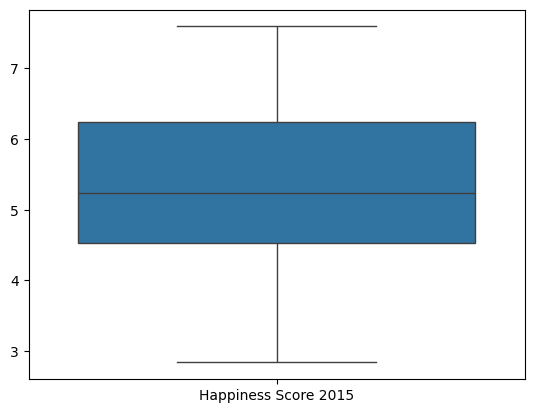

In [942]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly

# Box Plot to find outliers in 2015 dataset...
sns.boxplot(data=data_2015[['Happiness Score 2015']])
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

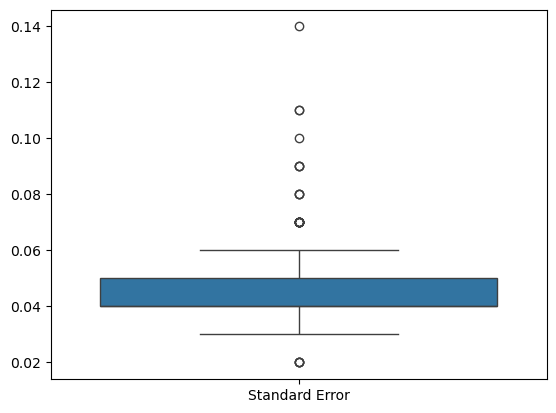

In [943]:
sns.boxplot(data=data_2015[['Standard Error']])
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

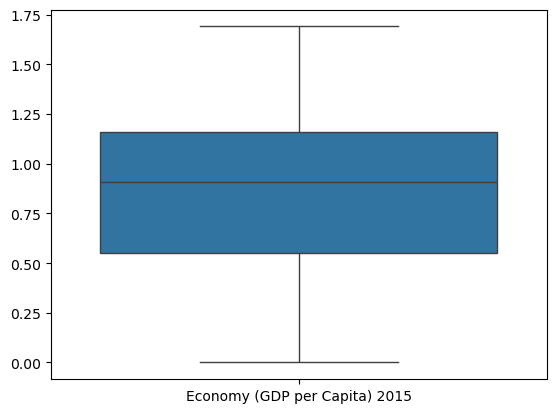

In [944]:
sns.boxplot(data=data_2015[['Economy (GDP per Capita) 2015']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

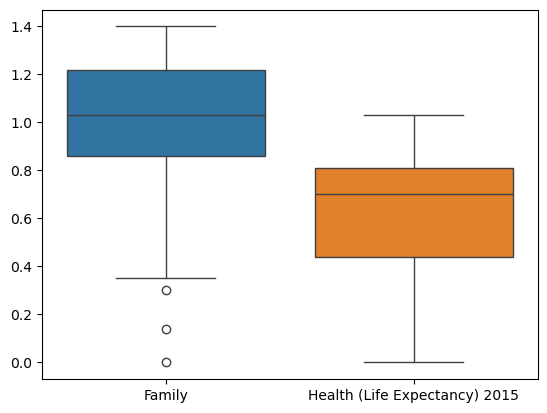

In [945]:
sns.boxplot(data=data_2015[['Family','Health (Life Expectancy) 2015']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

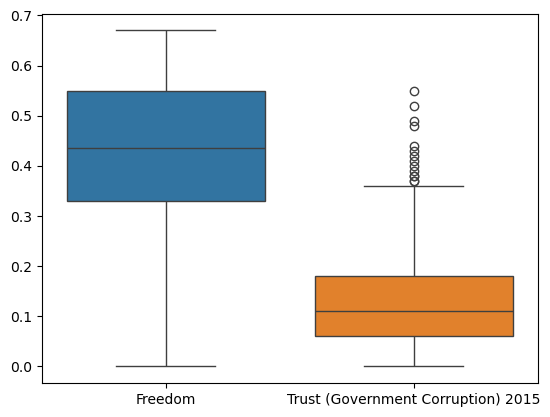

In [947]:
sns.boxplot(data=data_2015[['Freedom','Trust (Government Corruption) 2015']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

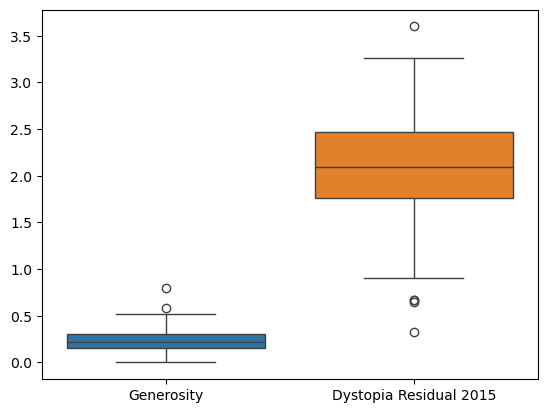

In [948]:
sns.boxplot(data=data_2015[['Generosity','Dystopia Residual 2015']])
plt.show

### 2015 Dataset Outliers
##### in 2015 there are multible columns with recognizable outliers which are
###### 1.Dystopia Residual 2015
###### 2.Trust (Government Corruption) 2015
###### 3.Standard Error
###### 4.Family 

<function matplotlib.pyplot.show(close=None, block=None)>

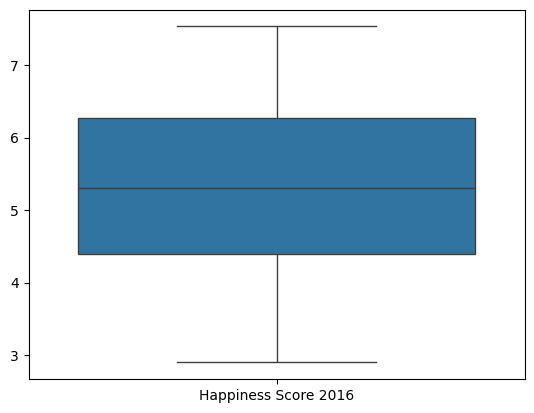

In [950]:
# Box Plot to find outliers in 2016 dataset...
sns.boxplot(data=data_2016[['Happiness Score 2016']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

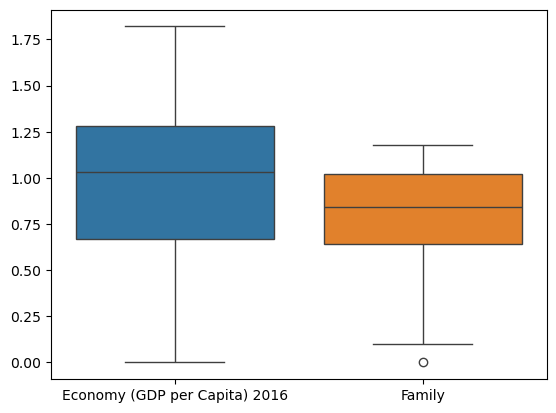

In [951]:
sns.boxplot(data=data_2016[['Economy (GDP per Capita) 2016', 'Family']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

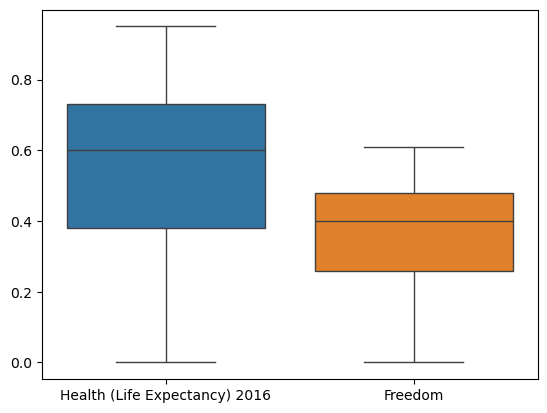

In [965]:
sns.boxplot(data=data_2016[['Health (Life Expectancy) 2016', 'Freedom']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

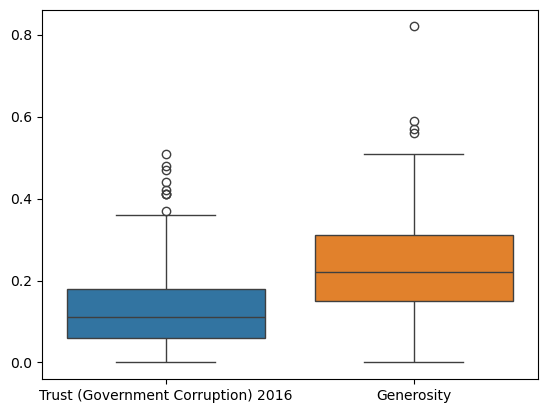

In [966]:
sns.boxplot(data=data_2016[['Trust (Government Corruption) 2016', 'Generosity']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

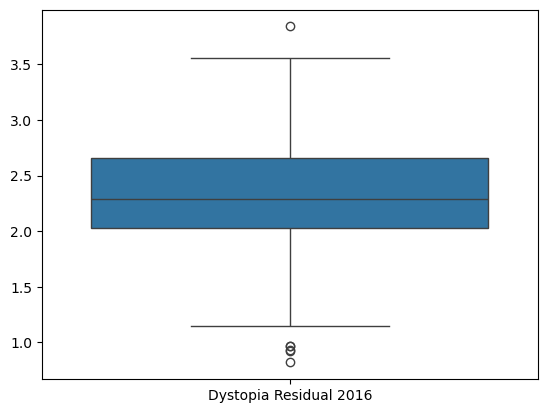

In [967]:
sns.boxplot(data=data_2016[['Dystopia Residual 2016']])
plt.show

### 2016 Dataset Outliers
##### In 2016 dataset there are multiple columns with outliers  
##### 1.Dystopia Residual 2016
##### 2.Trust (Government Corruption) 2016
##### 3.Generosity
##### 4.Family

In [970]:
data_2017.columns

Index(['Country', 'Happiness Rank 2017', 'Happiness Score 2017',
       'Whisker.high', 'Whisker.low', 'Economy (GDP per Capita) 2017',
       'Family', 'Health (Life Expectancy) 2017', 'Freedom', 'Generosity',
       'Trust (Government Corruption) 2017', 'Dystopia Residual 2017'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

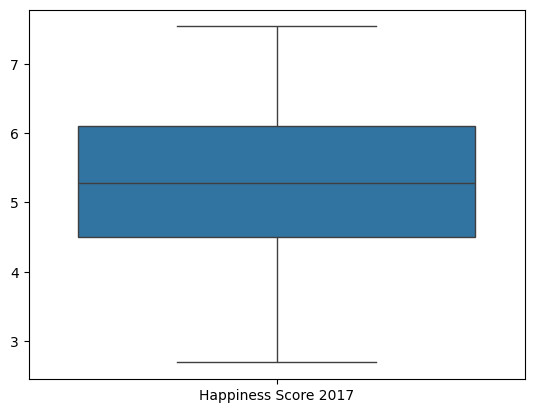

In [971]:
# Box Plot to find outliers in 2017 dataset...
sns.boxplot(data=data_2017[['Happiness Score 2017']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

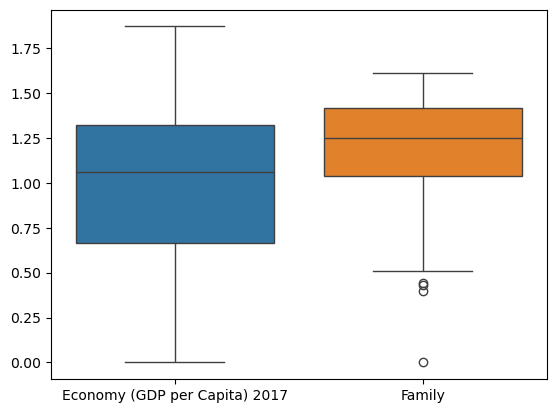

In [972]:
sns.boxplot(data=data_2017[['Economy (GDP per Capita) 2017', 'Family']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

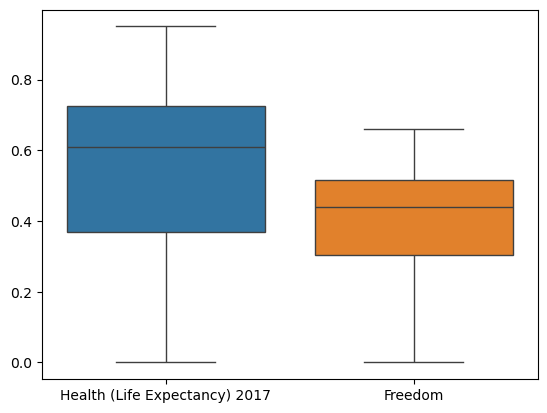

In [973]:
sns.boxplot(data=data_2017[['Health (Life Expectancy) 2017', 'Freedom']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

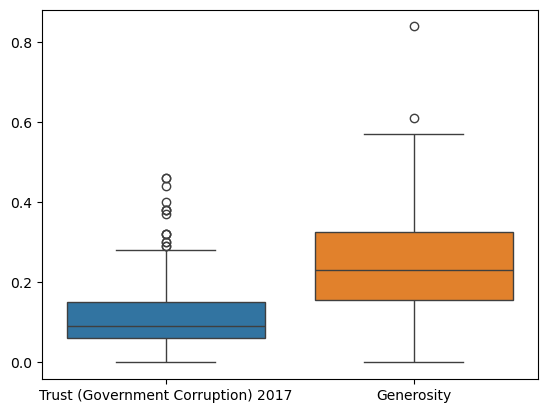

In [975]:
sns.boxplot(data=data_2017[['Trust (Government Corruption) 2017', 'Generosity']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

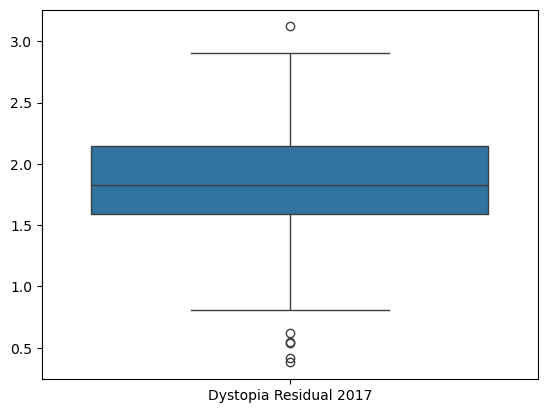

In [977]:
sns.boxplot(data=data_2017[['Dystopia Residual 2017']])
plt.show

### 2017 Dataset Outliers
##### In 2017 dataset there are multiple columns with outliers  
##### 1.Dystopia Residual 2017
##### 2.Trust (Government Corruption) 2017
##### 3.Generosity
##### 4.Family

<function matplotlib.pyplot.show(close=None, block=None)>

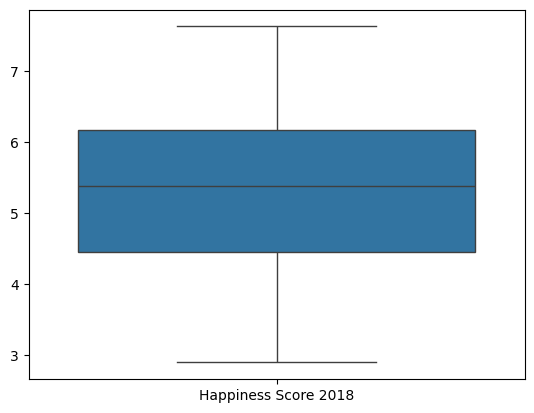

In [979]:
# Box Plot to find outliers in 2018 dataset...
sns.boxplot(data=data_2018[['Happiness Score 2018']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

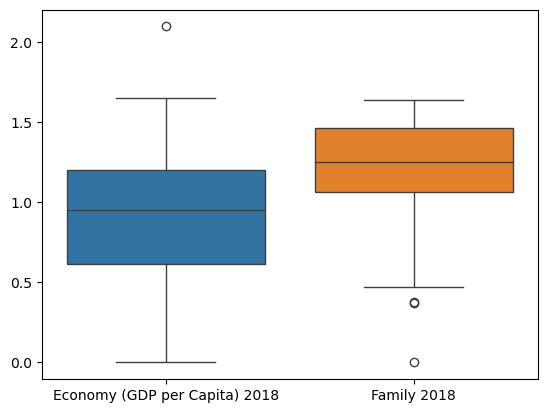

In [981]:
sns.boxplot(data=data_2018[['Economy (GDP per Capita) 2018', 'Family 2018']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

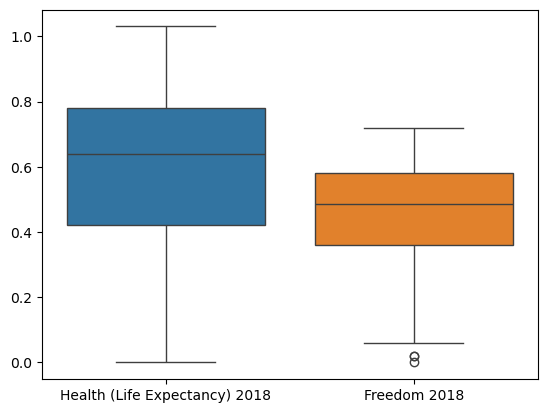

In [982]:
sns.boxplot(data=data_2018[['Health (Life Expectancy) 2018', 'Freedom 2018']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

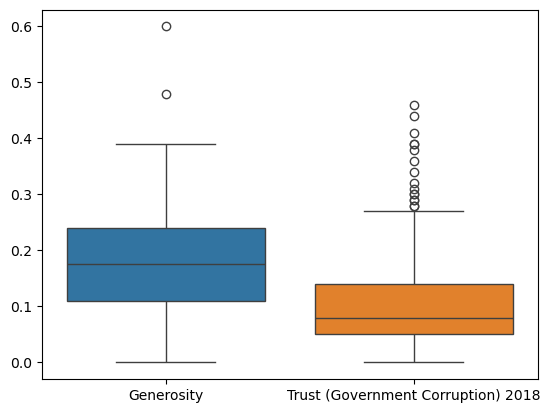

In [983]:
sns.boxplot(data=data_2018[['Generosity','Trust (Government Corruption) 2018']])
plt.show

### 2018 Dataset Outliers
##### In 2018 dataset there are multiple columns with outliers  
##### 1.Freedom 2018
##### 2.Trust (Government Corruption) 2018
##### 3.Generosity
##### 4.Family
##### 5.Economy (GDP per Capita) 2018

<function matplotlib.pyplot.show(close=None, block=None)>

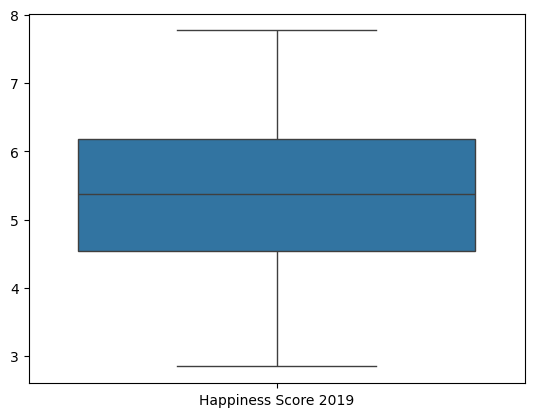

In [987]:
# Box Plot to find outliers in 2019 dataset...
sns.boxplot(data=data_2019[['Happiness Score 2019']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

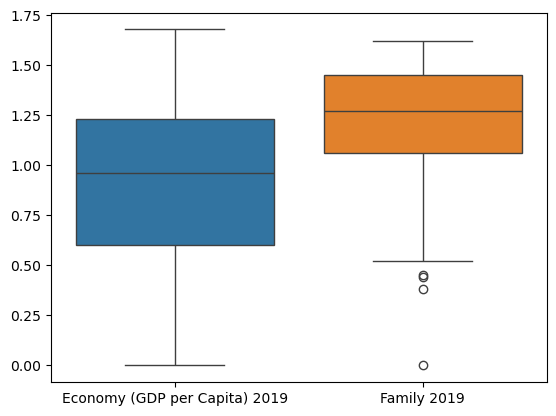

In [989]:
sns.boxplot(data=data_2019[['Economy (GDP per Capita) 2019', 'Family 2019']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

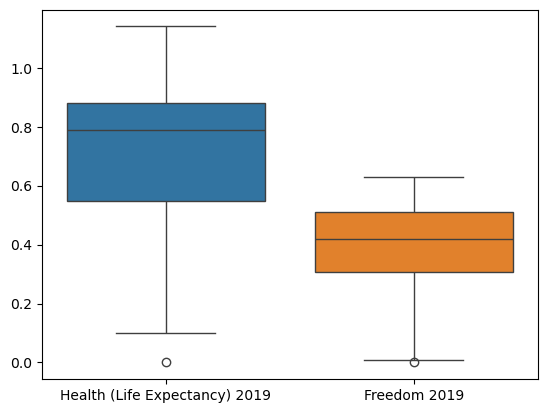

In [991]:
sns.boxplot(data=data_2019[['Health (Life Expectancy) 2019', 'Freedom 2019']])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

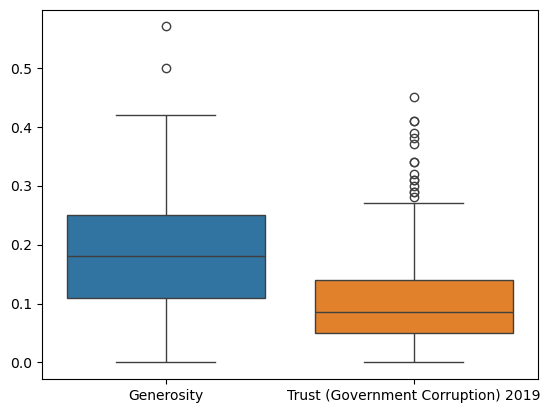

In [992]:
sns.boxplot(data=data_2019[['Generosity','Trust (Government Corruption) 2019']])
plt.show

### 2019 Dataset Outliers
##### In 2019 dataset there are multiple columns with outliers  
##### 1.Freedom 2019
##### 2.Trust (Government Corruption) 2019
##### 3.Generosity
##### 4.Family
##### 5.Health (Life Expectancy) 2019

In [996]:
data_2015.columns

Index(['Country', 'Region', 'Happiness Rank 2015', 'Happiness Score 2015',
       'Standard Error', 'Economy (GDP per Capita) 2015', 'Family',
       'Health (Life Expectancy) 2015', 'Freedom',
       'Trust (Government Corruption) 2015', 'Generosity',
       'Dystopia Residual 2015'],
      dtype='object')

In [1114]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 
#  Z-Score Method to detect outliers in 2015
# first take subset of 2015 dtaframe to take only numeric values columns

# Step 1: Separate numeric columns
numeric_data = data_2015.select_dtypes(include=[np.number])

# Step 2: Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_data))

# Step 3: Set a threshold for outliers
threshold = 3

# Step 4: Create a mask for rows without outliers
mask = (z_scores <= threshold).all(axis=1)

# Step 5: Filter the original DataFrame using the mask
filtered_data_2015 = data_2015[mask]

# Step 6: Display the filtered DataFrame
print("Filtered DataFrame:")
#print(filtered_data)

# Step 7: Check shapes to confirm removal
print(f"Original shape: {data_2015.shape}")
print(f"Filtered shape: {filtered_data_2015.shape}")


Filtered DataFrame:
Original shape: (158, 12)
Filtered shape: (149, 12)


In [1116]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 
#  Z-Score Method to detect outliers in 2015
# first take subset of 2015 dtaframe to take only numeric values columns

# Step 1: Separate numeric columns
numeric_data = data_2016.select_dtypes(include=[np.number])

# Step 2: Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_data))

# Step 3: Set a threshold for outliers
threshold = 3

# Step 4: Create a mask for rows without outliers
mask = (z_scores <= threshold).all(axis=1)

# Step 5: Filter the original DataFrame using the mask
filtered_data_2016 = data_2016[mask]

# Step 6: Display the filtered DataFrame
print("Filtered DataFrame:")
#print(filtered_data)

# Step 7: Check shapes to confirm removal
print(f"Original shape: {data_2016.shape}")
print(f"Filtered shape: {filtered_data_2016.shape}")


Filtered DataFrame:
Original shape: (157, 13)
Filtered shape: (153, 13)


In [1118]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 
#  Z-Score Method to detect outliers in 2015
# first take subset of 2015 dtaframe to take only numeric values columns

# Step 1: Separate numeric columns
numeric_data = data_2017.select_dtypes(include=[np.number])

# Step 2: Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_data))

# Step 3: Set a threshold for outliers
threshold = 3

# Step 4: Create a mask for rows without outliers
mask = (z_scores <= threshold).all(axis=1)

# Step 5: Filter the original DataFrame using the mask
filtered_data_2017 = data_2017[mask]

# Step 6: Display the filtered DataFrame
print("Filtered DataFrame:")
#print(filtered_data)

# Step 7: Check shapes to confirm removal
print(f"Original shape: {data_2017.shape}")
print(f"Filtered shape: {filtered_data_2017.shape}")


Filtered DataFrame:
Original shape: (155, 12)
Filtered shape: (150, 12)


In [1120]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 
#  Z-Score Method to detect outliers in 2015
# first take subset of 2015 dtaframe to take only numeric values columns

# Step 1: Separate numeric columns
numeric_data = data_2018.select_dtypes(include=[np.number])

# Step 2: Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_data))

# Step 3: Set a threshold for outliers
threshold = 3

# Step 4: Create a mask for rows without outliers
mask = (z_scores <= threshold).all(axis=1)

# Step 5: Filter the original DataFrame using the mask
filtered_data_2018 = data_2018[mask]

# Step 6: Display the filtered DataFrame
print("Filtered DataFrame:")
#print(filtered_data)

# Step 7: Check shapes to confirm removal
print(f"Original shape: {data_2018.shape}")
print(f"Filtered shape: {filtered_data_2018.shape}")


Filtered DataFrame:
Original shape: (156, 9)
Filtered shape: (149, 9)


In [1122]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 
#  Z-Score Method to detect outliers in 2015
# first take subset of 2015 dtaframe to take only numeric values columns

# Step 1: Separate numeric columns
numeric_data = data_2019.select_dtypes(include=[np.number])

# Step 2: Calculate Z-scores for numeric columns
z_scores = np.abs(stats.zscore(numeric_data))

# Step 3: Set a threshold for outliers
threshold = 3

# Step 4: Create a mask for rows without outliers
mask = (z_scores <= threshold).all(axis=1)

# Step 5: Filter the original DataFrame using the mask
filtered_data_2019 = data_2019[mask]

# Step 6: Display the filtered DataFrame
print("Filtered DataFrame:")
#print(filtered_data)

# Step 7: Check shapes to confirm removal
print(f"Original shape: {data_2019.shape}")
print(f"Filtered shape: {filtered_data_2019.shape}")


Filtered DataFrame:
Original shape: (156, 9)
Filtered shape: (149, 9)


## 2. Data Cleaning: 

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



### Handling missing values:

**Why my data has missing values?**
They may occur at two stages:
1. Data Extraction: It is possible that there are problems with extraction process. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
2. Data collection: These errors occur at time of data collection and are harder to correct.

**Why do we need to handle the missing data?**
To avoid:
- Bias the conclusions.
- Leading the business to make wrong decisions.

**Which are the methods to treat missing values ?**
1. Deletion: we delete rows where any of the variable is missing. Simplicity is one of the major advantage of this method, but this method reduces the power of model because it reduces the sample size.

2. Imputation: is a method to fill in the missing values with estimated ones. This imputation is one of the most frequently used methods.

    2.1. Mean/ Mode/ Median Imputation: It consists of replacing the missing data for a given attribute by the mean or median (quantitative attribute) or mode (qualitative attribute) of all known values of that variable.
    > It can be of two types:
    > - Generalized Imputation: In this case, we calculate the mean or median for all non missing values of that variable then replace missing value with mean or median.
    > - Similar case Imputation: In this case, we calculate average for each group individually of non missing values then replace the missing value based on the group.

    2.2. Constant Value
   
    2.3. Forward Filling
   
    2.4. Backward Filling

6. Prediction Model:  Prediction model is one of the sophisticated method for handling missing data. Here, we create a predictive model to estimate values that will substitute the missing data.  In this case, we divide our data set into two sets: One set with no missing values for the variable and another one with missing values. First data set become training data set of the model while second data set with missing values is test data set and variable with missing values is treated as target variable. Next, we create a model to predict target variable based on other attributes of the training data set and populate missing values of test data set.

> There are 2 drawbacks for this approach:
> - The model estimated values are usually more well-behaved than the true values
> - If there are no relationships with attributes in the data set and the attribute with missing values, then the model will not be precise for estimating missing values.

9. KNN Imputation: In this method of imputation, the missing values of an attribute are imputed using the given number of attributes that are most similar to the attribute whose values are missing. The similarity of two attributes is determined using a distance function. It is also known to have certain advantage & disadvantages.

   > **Advantages:**
   > - k-nearest neighbour can predict both qualitative & quantitative attributes
   > - Creation of predictive model for each attribute with missing data is not required
   > - Attributes with multiple missing values can be easily treated
   > - Correlation structure of the data is taken into consideration

   > **Disadvantage:**
   > - KNN algorithm is very time-consuming in analyzing large database. It searches through all the dataset looking for the most similar instances.
   > - Choice of k-value is very critical. Higher value of k would include attributes which are significantly different from what we need whereas lower value of k implies missing out of significant attributes.

--------------------


In [1124]:
# go back to 6th dimention --> Completeness
data_2015.isnull().sum().sort_values(ascending = False)

Country                               0
Region                                0
Happiness Rank 2015                   0
Happiness Score 2015                  0
Standard Error                        0
Economy (GDP per Capita) 2015         0
Family                                0
Health (Life Expectancy) 2015         0
Freedom                               0
Trust (Government Corruption) 2015    0
Generosity                            0
Dystopia Residual 2015                0
dtype: int64

In [1126]:
data_2016.isnull().sum().sort_values(ascending = False)

Country                               0
Region                                0
Happiness Rank 2016                   0
Happiness Score 2016                  0
Lower Confidence Interval             0
Upper Confidence Interval             0
Economy (GDP per Capita) 2016         0
Family                                0
Health (Life Expectancy) 2016         0
Freedom                               0
Trust (Government Corruption) 2016    0
Generosity                            0
Dystopia Residual 2016                0
dtype: int64

In [1128]:
data_2017.isnull().sum().sort_values(ascending = False)

Country                               0
Happiness Rank 2017                   0
Happiness Score 2017                  0
Whisker.high                          0
Whisker.low                           0
Economy (GDP per Capita) 2017         0
Family                                0
Health (Life Expectancy) 2017         0
Freedom                               0
Generosity                            0
Trust (Government Corruption) 2017    0
Dystopia Residual 2017                0
dtype: int64

In [1132]:
data_2018.isnull().sum().sort_values(ascending = False)

Happiness Rank 2018                   0
Country                               0
Happiness Score 2018                  0
Economy (GDP per Capita) 2018         0
Family 2018                           0
Health (Life Expectancy) 2018         0
Freedom 2018                          0
Generosity                            0
Trust (Government Corruption) 2018    0
dtype: int64

In [1134]:
data_2019.isnull().sum().sort_values(ascending = False)

Happiness Rank 2019                   0
Country                               0
Happiness Score 2019                  0
Economy (GDP per Capita) 2019         0
Family 2019                           0
Health (Life Expectancy) 2019         0
Freedom 2019                          0
Generosity                            0
Trust (Government Corruption) 2019    0
dtype: int64

### Correcting errors

-------------------

In [1136]:
# go back to 7th dimension Accuracy 
data_2015.head(2)

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015
0,Switzerland,Western Europe,1,7.59,0.03,1.4,1.35,0.94,0.67,0.42,0.30,2.52
1,Iceland,Western Europe,2,7.56,0.05,1.3,1.40,0.95,0.63,0.14,0.44,2.70


In [1138]:
data_2015.dtypes

Country                                object
Region                                 object
Happiness Rank 2015                     int64
Happiness Score 2015                  float64
Standard Error                        float64
Economy (GDP per Capita) 2015         float64
Family                                float64
Health (Life Expectancy) 2015         float64
Freedom                               float64
Trust (Government Corruption) 2015    float64
Generosity                            float64
Dystopia Residual 2015                float64
dtype: object

In [1140]:
data_2016.head(2)

,Country,Region,Happiness Rank 2016,Happiness Score 2016,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita) 2016,Family,Health (Life Expectancy) 2016,Freedom,Trust (Government Corruption) 2016,Generosity,Dystopia Residual 2016
0,Denmark,Western Europe,1,7.53,7.460,7.592,1.44,1.16,0.80,0.58,0.44,0.36,2.74
1,Switzerland,Western Europe,2,7.51,7.428,7.590,1.53,1.15,0.86,0.59,0.41,0.28,2.69


In [1142]:
data_2016.dtypes

Country                                object
Region                                 object
Happiness Rank 2016                     int64
Happiness Score 2016                  float64
Lower Confidence Interval             float64
Upper Confidence Interval             float64
Economy (GDP per Capita) 2016         float64
Family                                float64
Health (Life Expectancy) 2016         float64
Freedom                               float64
Trust (Government Corruption) 2016    float64
Generosity                            float64
Dystopia Residual 2016                float64
dtype: object

In [1144]:
data_2017.head(2)

,Country,Happiness Rank 2017,Happiness Score 2017,Whisker.high,Whisker.low,Economy (GDP per Capita) 2017,Family,Health (Life Expectancy) 2017,Freedom,Generosity,Trust (Government Corruption) 2017,Dystopia Residual 2017
0,Norway,1,7.54,7.594445,7.479556,1.62,1.53,0.80,0.64,0.36,0.32,2.28
1,Denmark,2,7.52,7.581728,7.462272,1.48,1.55,0.79,0.63,0.36,0.40,2.31


In [1146]:
data_2017.dtypes

Country                                object
Happiness Rank 2017                     int64
Happiness Score 2017                  float64
Whisker.high                          float64
Whisker.low                           float64
Economy (GDP per Capita) 2017         float64
Family                                float64
Health (Life Expectancy) 2017         float64
Freedom                               float64
Generosity                            float64
Trust (Government Corruption) 2017    float64
Dystopia Residual 2017                float64
dtype: object

In [1148]:
data_2018.head(2)

,Happiness Rank 2018,Country,Happiness Score 2018,Economy (GDP per Capita) 2018,Family 2018,Health (Life Expectancy) 2018,Freedom 2018,Generosity,Trust (Government Corruption) 2018
0,1,Finland,7.63,1.30,1.59,0.87,0.68,0.20,0.39
1,2,Norway,7.59,1.46,1.58,0.86,0.69,0.29,0.34


In [1150]:
data_2018.dtypes

Happiness Rank 2018                     int64
Country                                object
Happiness Score 2018                  float64
Economy (GDP per Capita) 2018         float64
Family 2018                           float64
Health (Life Expectancy) 2018         float64
Freedom 2018                          float64
Generosity                            float64
Trust (Government Corruption) 2018    float64
dtype: object

In [1152]:
data_2019.head(2)

,Happiness Rank 2019,Country,Happiness Score 2019,Economy (GDP per Capita) 2019,Family 2019,Health (Life Expectancy) 2019,Freedom 2019,Generosity,Trust (Government Corruption) 2019
0,1,Finland,7.77,1.34,1.59,0.99,0.60,0.15,0.39
1,2,Denmark,7.60,1.38,1.57,1.00,0.59,0.25,0.41


In [1154]:
data_2019.dtypes

Happiness Rank 2019                     int64
Country                                object
Happiness Score 2019                  float64
Economy (GDP per Capita) 2019         float64
Family 2019                           float64
Health (Life Expectancy) 2019         float64
Freedom 2019                          float64
Generosity                            float64
Trust (Government Corruption) 2019    float64
dtype: object

## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

In [1156]:
data_2015.head(2)

,Country,Region,Happiness Rank 2015,Happiness Score 2015,Standard Error,Economy (GDP per Capita) 2015,Family,Health (Life Expectancy) 2015,Freedom,Trust (Government Corruption) 2015,Generosity,Dystopia Residual 2015
0,Switzerland,Western Europe,1,7.59,0.03,1.4,1.35,0.94,0.67,0.42,0.30,2.52
1,Iceland,Western Europe,2,7.56,0.05,1.3,1.40,0.95,0.63,0.14,0.44,2.70


#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

In [1166]:
counts_of_region=data_2015['Region'].value_counts()

In [1170]:
counts_of_region.index

Index(['Sub-Saharan Africa', 'Central and Eastern Europe',
       'Latin America and Caribbean', 'Western Europe',
       'Middle East and Northern Africa', 'Southeastern Asia', 'Southern Asia',
       'Eastern Asia', 'North America', 'Australia and New Zealand'],
      dtype='object', name='Region')

In [1172]:
counts_of_region.values

array([40, 29, 22, 21, 20,  9,  7,  6,  2,  2], dtype=int64)

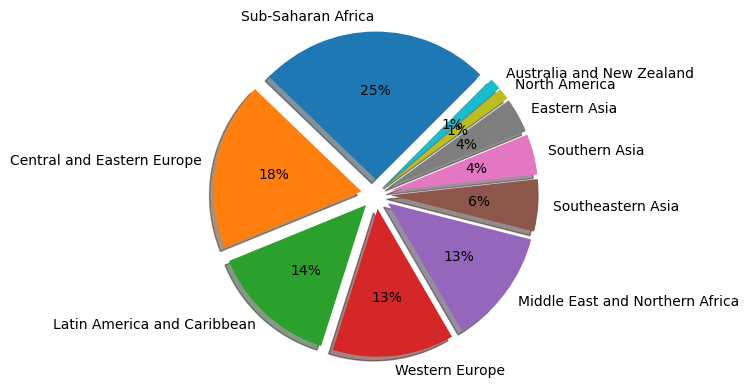

In [1184]:
plt.pie(x=counts_of_region.values,
        labels=counts_of_region.index,
        autopct='%1.0f%%',
        startangle=45,
        shadow=True,
  explode=[0.1]*len(counts_of_region),)
plt.show()

### What countries or regions rank the highest in overall happiness and each of the six factors contributing to happiness?

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Switzerland'),
  Text(1, 0, 'Iceland'),
  Text(2, 0, 'Denmark'),
  Text(3, 0, 'Norway'),
  Text(4, 0, 'Canada'),
  Text(5, 0, 'Finland'),
  Text(6, 0, 'Netherlands'),
  Text(7, 0, 'Sweden'),
  Text(8, 0, 'New Zealand'),
  Text(9, 0, 'Israel'),
  Text(10, 0, 'Australia'),
  Text(11, 0, 'Costa Rica'),
  Text(12, 0, 'Austria'),
  Text(13, 0, 'Mexico'),
  Text(14, 0, 'United States')])

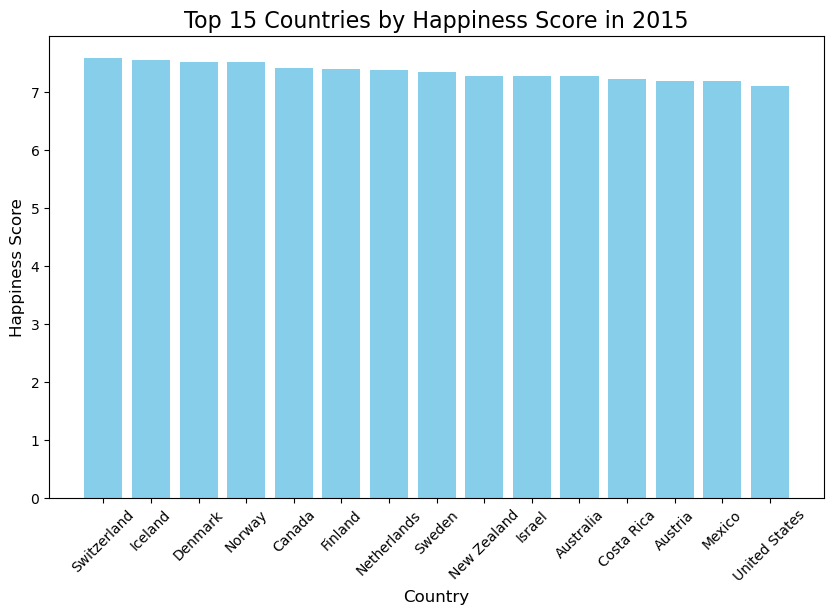

In [1196]:
# Step 1: Sort the DataFrame by 'Happiness Score 2015' in descending order
top_countries = data_2015.sort_values(by='Happiness Score 2015', ascending=False).head(15)

# Step 2: Set the figure size
plt.figure(figsize=(10, 6))

# Step 3: Create a bar chart for the top 15 countries
plt.bar(top_countries['Country'], top_countries['Happiness Score 2015'], color='skyblue')

# Step 4: Add labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Top 15 Countries by Happiness Score in 2015', fontsize=16)

# Step 5: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 6: Show the plot

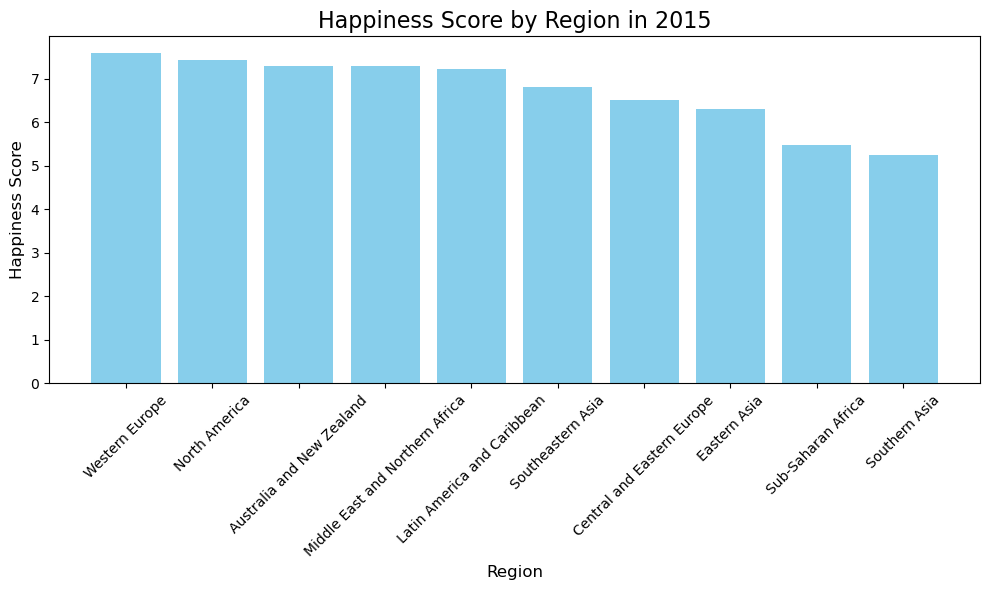

In [1200]:
plt.figure(figsize=(10, 6))

# Step 2: Create a bar chart
plt.bar(data_2015['Region'], data_2015['Happiness Score 2015'], color='skyblue')

# Step 3: Add labels and title
plt.xlabel('Region', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness Score by Region in 2015', fontsize=16)

# Step 4: Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45)

# Step 5: Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()
# Step 6: Show the plot

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Denmark'),
  Text(1, 0, 'Switzerland'),
  Text(2, 0, 'Iceland'),
  Text(3, 0, 'Norway'),
  Text(4, 0, 'Finland'),
  Text(5, 0, 'Canada'),
  Text(6, 0, 'Netherlands'),
  Text(7, 0, 'New Zealand'),
  Text(8, 0, 'Australia'),
  Text(9, 0, 'Sweden'),
  Text(10, 0, 'Israel'),
  Text(11, 0, 'Austria'),
  Text(12, 0, 'United States'),
  Text(13, 0, 'Costa Rica'),
  Text(14, 0, 'Puerto Rico')])

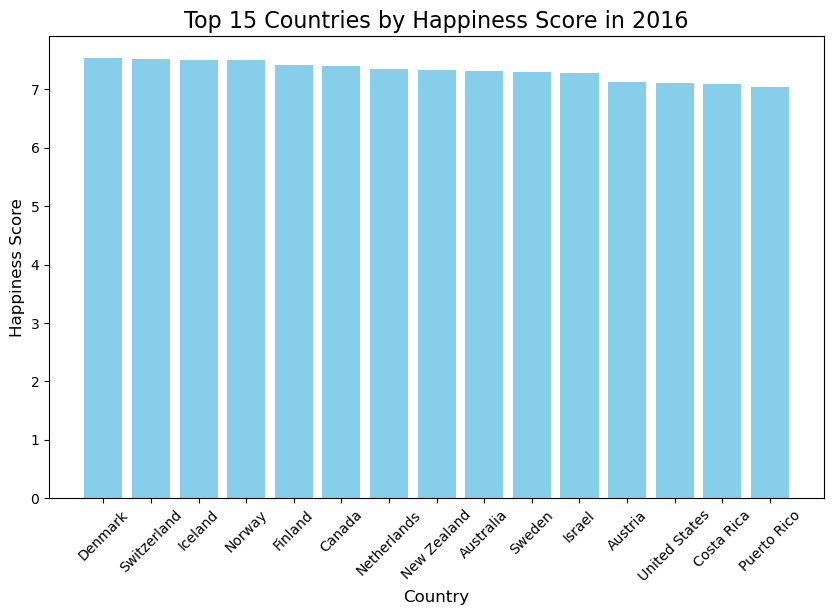

In [1202]:
# Step 1: Sort the DataFrame by 'Happiness Score 2015' in descending order
top_countries = data_2016.sort_values(by='Happiness Score 2016', ascending=False).head(15)

# Step 2: Set the figure size
plt.figure(figsize=(10, 6))

# Step 3: Create a bar chart for the top 15 countries
plt.bar(top_countries['Country'], top_countries['Happiness Score 2016'], color='skyblue')

# Step 4: Add labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Top 15 Countries by Happiness Score in 2016', fontsize=16)

# Step 5: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 6: Show the plot

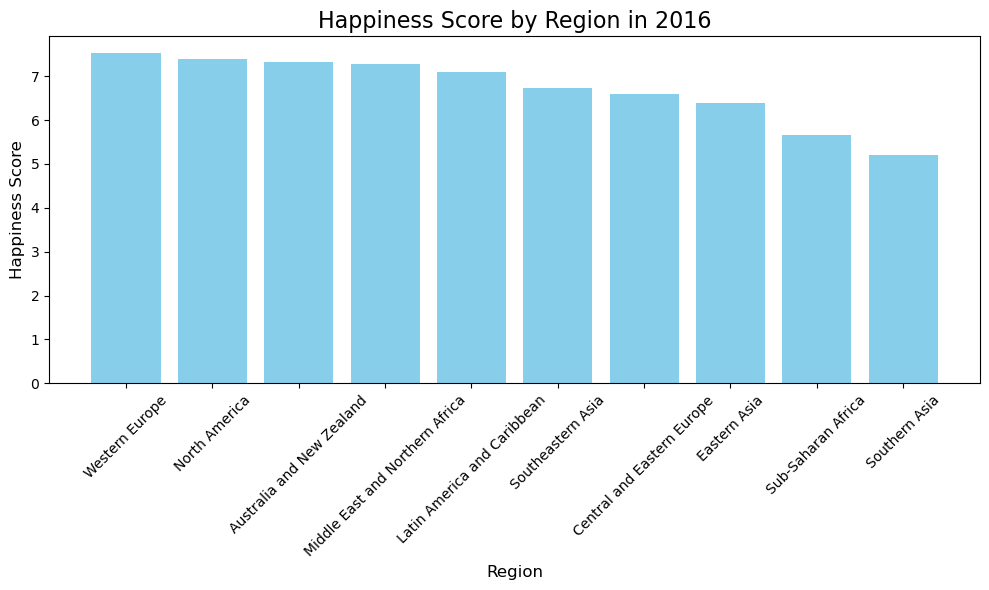

In [1204]:
plt.figure(figsize=(10, 6))

# Step 2: Create a bar chart
plt.bar(data_2016['Region'], data_2016['Happiness Score 2016'], color='skyblue')

# Step 3: Add labels and title
plt.xlabel('Region', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness Score by Region in 2016', fontsize=16)

# Step 4: Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45)

# Step 5: Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()
# Step 6: Show the plot

In [1208]:
data_2017.columns

Index(['Country', 'Happiness Rank 2017', 'Happiness Score 2017',
       'Whisker.high', 'Whisker.low', 'Economy (GDP per Capita) 2017',
       'Family', 'Health (Life Expectancy) 2017', 'Freedom', 'Generosity',
       'Trust (Government Corruption) 2017', 'Dystopia Residual 2017'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Norway'),
  Text(1, 0, 'Denmark'),
  Text(2, 0, 'Iceland'),
  Text(3, 0, 'Switzerland'),
  Text(4, 0, 'Finland'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Canada'),
  Text(7, 0, 'New Zealand'),
  Text(8, 0, 'Sweden'),
  Text(9, 0, 'Australia'),
  Text(10, 0, 'Israel'),
  Text(11, 0, 'Costa Rica'),
  Text(12, 0, 'Austria'),
  Text(13, 0, 'United States'),
  Text(14, 0, 'Ireland')])

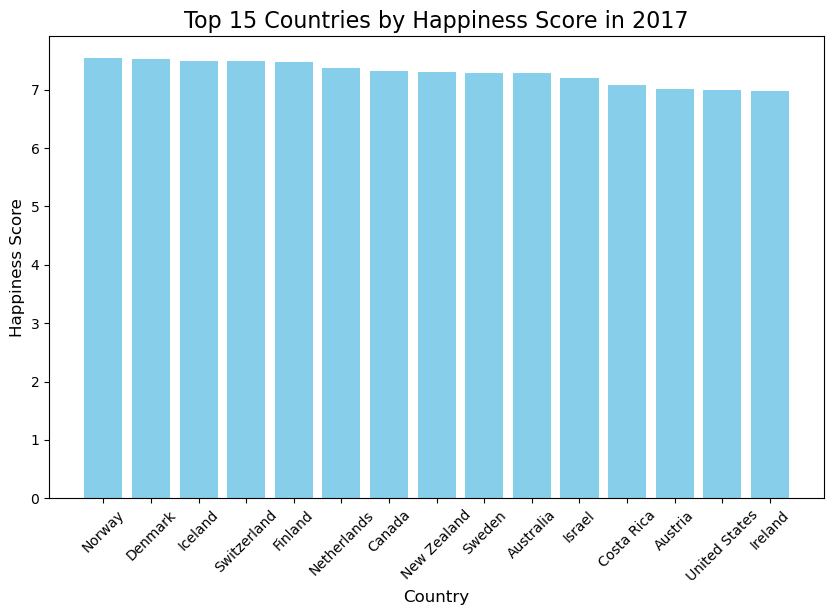

In [1210]:
# Step 1: Sort the DataFrame by 'Happiness Score 2015' in descending order
top_countries = data_2017.sort_values(by='Happiness Score 2017', ascending=False).head(15)

# Step 2: Set the figure size
plt.figure(figsize=(10, 6))

# Step 3: Create a bar chart for the top 15 countries
plt.bar(top_countries['Country'], top_countries['Happiness Score 2017'], color='skyblue')

# Step 4: Add labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Top 15 Countries by Happiness Score in 2017', fontsize=16)

# Step 5: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 6: Show the plot

In [1220]:
data_2018.columns

Index(['Happiness Rank 2018', 'Country', 'Happiness Score 2018',
       'Economy (GDP per Capita) 2018', 'Family 2018',
       'Health (Life Expectancy) 2018', 'Freedom 2018', 'Generosity',
       'Trust (Government Corruption) 2018'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Finland'),
  Text(1, 0, 'Norway'),
  Text(2, 0, 'Denmark'),
  Text(3, 0, 'Iceland'),
  Text(4, 0, 'Switzerland'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Canada'),
  Text(7, 0, 'New Zealand'),
  Text(8, 0, 'Sweden'),
  Text(9, 0, 'Australia'),
  Text(10, 0, 'United Kingdom'),
  Text(11, 0, 'Austria'),
  Text(12, 0, 'Costa Rica'),
  Text(13, 0, 'Ireland'),
  Text(14, 0, 'Germany')])

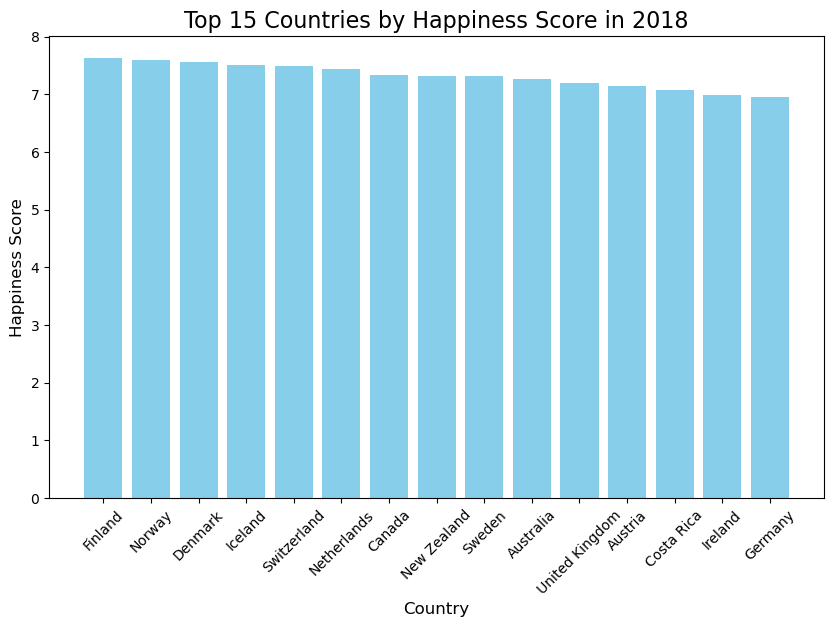

In [1212]:
# Step 1: Sort the DataFrame by 'Happiness Score 2015' in descending order
top_countries = data_2018.sort_values(by='Happiness Score 2018', ascending=False).head(15)

# Step 2: Set the figure size
plt.figure(figsize=(10, 6))

# Step 3: Create a bar chart for the top 15 countries
plt.bar(top_countries['Country'], top_countries['Happiness Score 2018'], color='skyblue')

# Step 4: Add labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Top 15 Countries by Happiness Score in 2018', fontsize=16)

# Step 5: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 6: Show the plot

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Finland'),
  Text(1, 0, 'Denmark'),
  Text(2, 0, 'Norway'),
  Text(3, 0, 'Iceland'),
  Text(4, 0, 'Netherlands'),
  Text(5, 0, 'Switzerland'),
  Text(6, 0, 'Sweden'),
  Text(7, 0, 'New Zealand'),
  Text(8, 0, 'Canada'),
  Text(9, 0, 'Austria'),
  Text(10, 0, 'Australia'),
  Text(11, 0, 'Costa Rica'),
  Text(12, 0, 'Israel'),
  Text(13, 0, 'Luxembourg'),
  Text(14, 0, 'United Kingdom')])

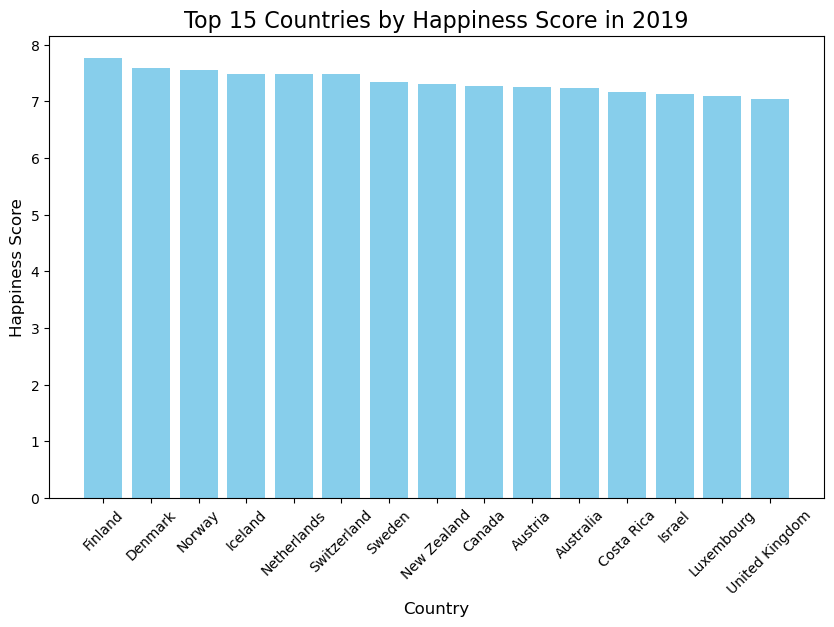

In [1216]:
# Step 1: Sort the DataFrame by 'Happiness Score 2015' in descending order
top_countries = data_2019.sort_values(by='Happiness Score 2019', ascending=False).head(15)

# Step 2: Set the figure size
plt.figure(figsize=(10, 6))

# Step 3: Create a bar chart for the top 15 countries
plt.bar(top_countries['Country'], top_countries['Happiness Score 2019'], color='skyblue')

# Step 4: Add labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Top 15 Countries by Happiness Score in 2019', fontsize=16)

# Step 5: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 6: Show the plot

### How did country ranks or scores change between the 2015 and 2016 as well as the 2016 and 2017 reports?

##### To answer such question we need to track how the score has changed across 2015 ,2016 and 2017 we need to merge data based in a common column which is country name 

In [1278]:
data_2015.columns


Index(['Country', 'Region', 'Happiness Rank 2015', 'Happiness Score 2015',
       'Standard Error', 'Economy (GDP per Capita) 2015', 'Family',
       'Health (Life Expectancy) 2015', 'Freedom',
       'Trust (Government Corruption) 2015', 'Generosity',
       'Dystopia Residual 2015'],
      dtype='object')

In [1280]:
# Keep only relevant columns from each year
data_2015_subset = data_2015[['Country', 'Happiness Rank 2015', 'Happiness Score 2015']]
data_2016_subset = data_2016[['Country', 'Happiness Rank 2016', 'Happiness Score 2016']]
data_2017_subset = data_2017[['Country', 'Happiness Rank 2017', 'Happiness Score 2017']]

# Merge datasets on 'Country'
merged_data = data_2015_subset.merge(data_2016_subset, on='Country', how='outer')
merged_data = merged_data.merge(data_2017_subset, on='Country', how='outer')


In [1282]:
# Calculate score changes
merged_data['Score Change 2015-2016'] = merged_data['Happiness Score 2016'] - merged_data['Happiness Score 2015']
merged_data['Score Change 2016-2017'] = merged_data['Happiness Score 2017'] - merged_data['Happiness Score 2016']

# Calculate rank changes
merged_data['Rank Change 2015-2016'] = merged_data['Happiness Rank 2015'] - merged_data['Happiness Rank 2016']
merged_data['Rank Change 2016-2017'] = merged_data['Happiness Rank 2016'] - merged_data['Happiness Rank 2017']


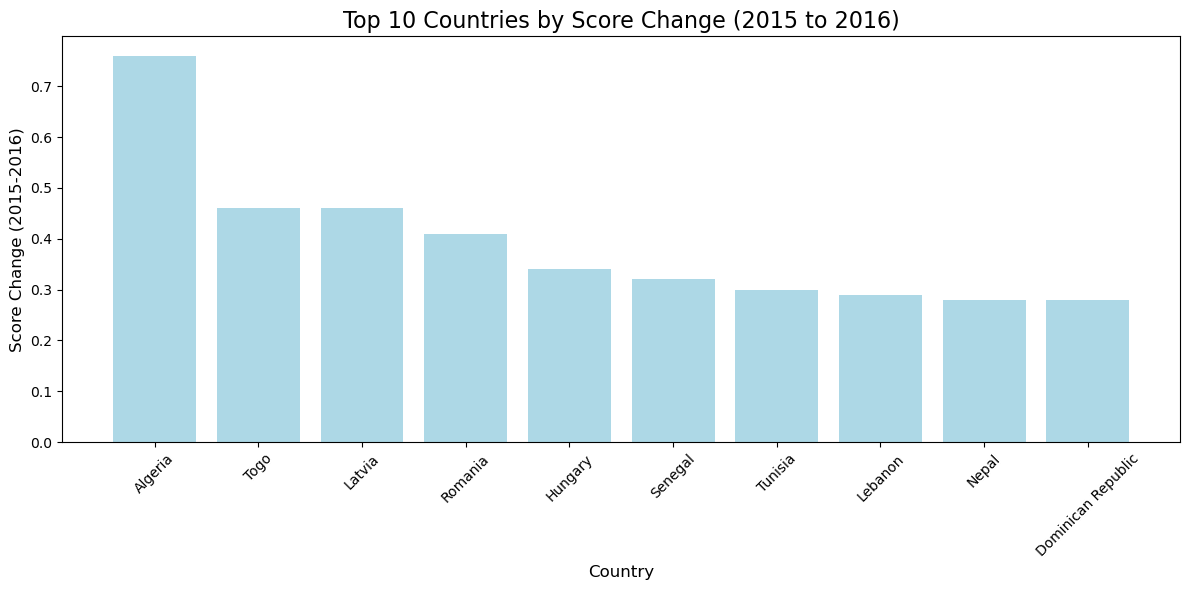

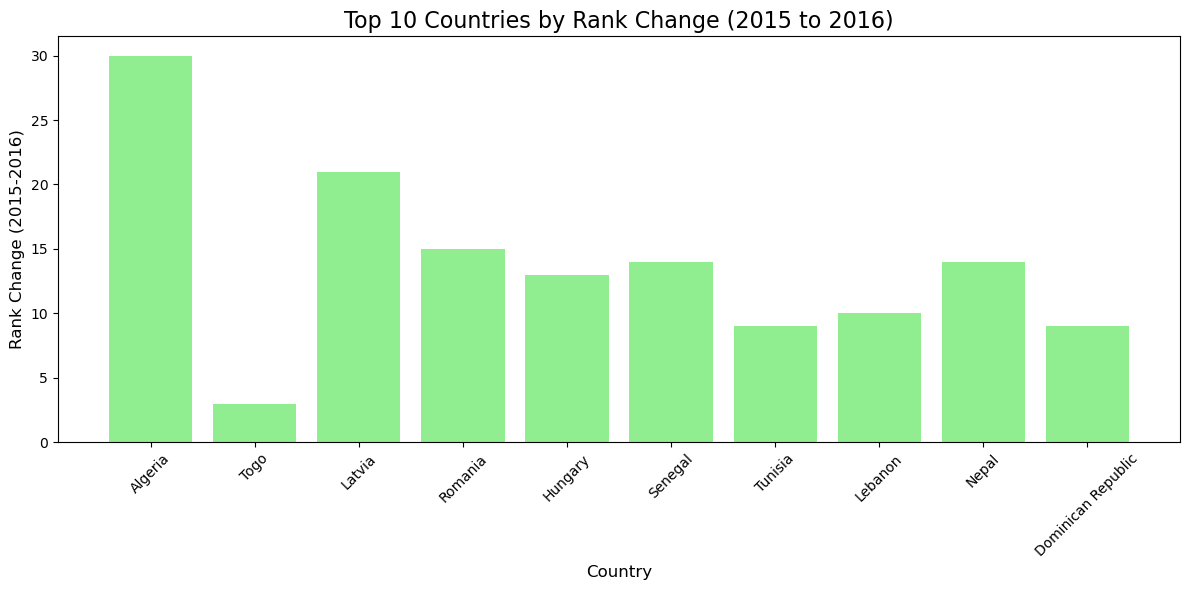

In [1284]:
# Show score changes for top 10 countries with the most improvement from 2015 to 2016
top_score_changes = merged_data.sort_values(by='Score Change 2015-2016', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_score_changes['Country'], top_score_changes['Score Change 2015-2016'], color='lightblue')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Score Change (2015-2016)', fontsize=12)
plt.title('Top 10 Countries by Score Change (2015 to 2016)', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Example: Show rank changes
plt.figure(figsize=(12, 6))
plt.bar(top_score_changes['Country'], top_score_changes['Rank Change 2015-2016'], color='lightgreen')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Rank Change (2015-2016)', fontsize=12)
plt.title('Top 10 Countries by Rank Change (2015 to 2016)', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1286]:
# Define a threshold for significant change
threshold = .1 

# Find countries with significant increases and decreases in happiness scores
significant_increases = merged_data[merged_data['Score Change 2015-2016'] > threshold]
significant_decreases = merged_data[merged_data['Score Change 2015-2016'] < -threshold]

# Display the results
print("Countries with Significant Increases in Happiness (2015-2016):")
print(significant_increases[['Country', 'Score Change 2015-2016']])

print("\nCountries with Significant Decreases in Happiness (2015-2016):")
print(significant_decreases[['Country', 'Score Change 2015-2016']])

# Repeat for 2016 to 2017
significant_increases_2016_2017 = merged_data[merged_data['Score Change 2016-2017'] > threshold]
significant_decreases_2016_2017 = merged_data[merged_data['Score Change 2016-2017'] < -threshold]

print("\nCountries with Significant Increases in Happiness (2016-2017):")
print(significant_increases_2016_2017[['Country', 'Score Change 2016-2017']])

print("\nCountries with Significant Decreases in Happiness (2016-2017):")
print(significant_decreases_2016_2017[['Country', 'Score Change 2016-2017']])


Countries with Significant Increases in Happiness (2015-2016):
                    Country  Score Change 2015-2016
2                   Algeria                    0.76
9                   Bahrain                    0.26
14                    Benin                    0.14
17   Bosnia and Herzegovina                    0.21
21             Burkina Faso                    0.15
24                 Cameroon                    0.26
29                    China                    0.10
32      Congo (Brazzaville)                    0.25
40       Dominican Republic                    0.28
42                    Egypt                    0.17
48                    Gabon                    0.22
50                  Germany                    0.24
52                   Greece                    0.17
53                Guatemala                    0.20
59                  Hungary                    0.34
63                     Iran                    0.12
68              Ivory Coast                    0.26
7

### Did any country experience a significant increase or decrease in happiness?

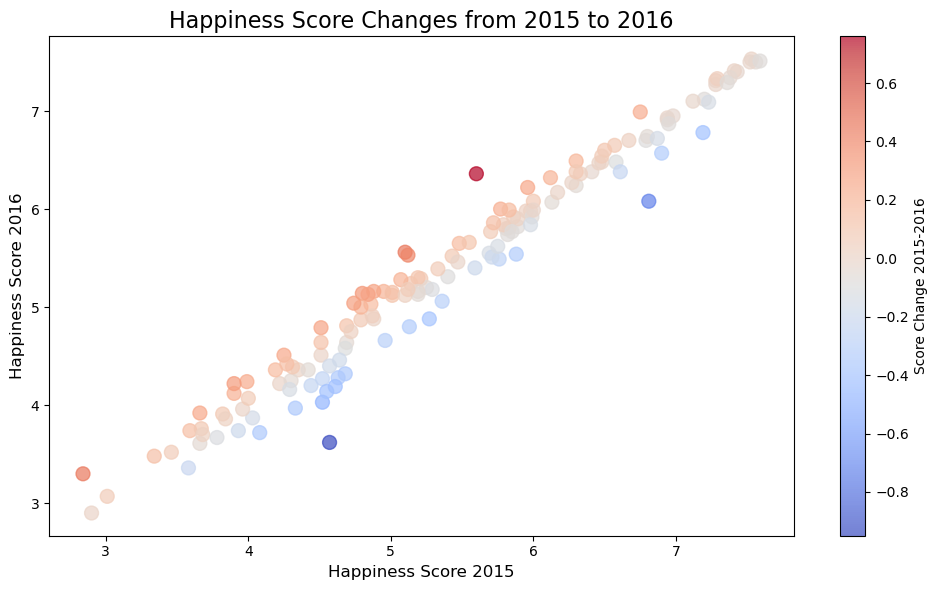

In [1267]:

# Create column for the change in happiness score from 2015 to 2016
merged_data['Score Change 2015-2016'] = merged_data['Happiness Score 2016'] - merged_data['Happiness Score 2015']

# Create a scatter plot to show the relationship between 2015 and 2016 happiness scores
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Happiness Score 2015'], merged_data['Happiness Score 2016'], 
            c=merged_data['Score Change 2015-2016'], cmap='coolwarm', s=100, alpha=0.7)

# Add labels and title
plt.xlabel('Happiness Score 2015', fontsize=12)
plt.ylabel('Happiness Score 2016', fontsize=12)
plt.title('Happiness Score Changes from 2015 to 2016', fontsize=16)

# Add a color bar to indicate the score changes
cbar = plt.colorbar()
cbar.set_label('Score Change 2015-2016')

# Show the plot
plt.tight_layout()
plt.show()


##### Color Indicating Change:
##### Points colored more towards the warm side (red) represent countries with a significant decrease in happiness from 2015 to 2016, while points with cooler colors (blue) represent countries with an increase.
##### Identifying Significant Changes:
##### Countries farther away from the diagonal line (where Happiness Score 2015 = Happiness Score 2016) are those that experienced the largest changes.


In [1274]:
#### To list the most significint country in increase or decrease i have used a threshold

In [1276]:
# Calculate the change in happiness scores between 2015-2016 and 2016-2017
merged_data['Score Change 2015-2016'] = merged_data['Happiness Score 2016'] - merged_data['Happiness Score 2015']
merged_data['Score Change 2016-2017'] = merged_data['Happiness Score 2017'] - merged_data['Happiness Score 2016']

# Define a threshold for significant change ( > 0.5 point increase or decrease)
threshold = 0.5

# Find countries with significant increases and decreases from 2015 to 2016
significant_increase_2015_2016 = merged_data[merged_data['Score Change 2015-2016'] > threshold][['Country', 'Score Change 2015-2016']]
significant_decrease_2015_2016 = merged_data[merged_data['Score Change 2015-2016'] < -threshold][['Country', 'Score Change 2015-2016']]

# Find countries with significant increases and decreases from 2016 to 2017
significant_increase_2016_2017 = merged_data[merged_data['Score Change 2016-2017'] > threshold][['Country', 'Score Change 2016-2017']]
significant_decrease_2016_2017 = merged_data[merged_data['Score Change 2016-2017'] < -threshold][['Country', 'Score Change 2016-2017']]

# Display the results
print("Countries with Significant Increases in Happiness (2015-2016):")
print(significant_increase_2015_2016)

print("\nCountries with Significant Decreases in Happiness (2015-2016):")
print(significant_decrease_2015_2016)

print("\nCountries with Significant Increases in Happiness (2016-2017):")
print(significant_increase_2016_2017)

print("\nCountries with Significant Decreases in Happiness (2016-2017):")
print(significant_decrease_2016_2017)


Countries with Significant Increases in Happiness (2015-2016):
   Country  Score Change 2015-2016
2  Algeria                    0.76

Countries with Significant Decreases in Happiness (2015-2016):
       Country  Score Change 2015-2016
81     Liberia                   -0.95
161  Venezuela                   -0.73

Countries with Significant Increases in Happiness (2016-2017):
Empty DataFrame
Columns: [Country, Score Change 2016-2017]
Index: []

Countries with Significant Decreases in Happiness (2016-2017):
       Country  Score Change 2016-2017
161  Venezuela                   -0.83


### Which countries had the highest and lowest happiness scores in 2015, and what might explain these rankings?

In [1257]:
# Find the country with the highest happiness score in 2015
highest_score_2015 = data_2015.nlargest(1, 'Happiness Score 2015')[['Country', 'Happiness Score 2015']]

# Find the country with the lowest happiness score in 2015
lowest_score_2015 = data_2015.nsmallest(1, 'Happiness Score 2015')[['Country', 'Happiness Score 2015']]

# Display the results
print("Country with the Highest Happiness Score in 2015:")
print(highest_score_2015)

print("\nCountry with the Lowest Happiness Score in 2015:")
print(lowest_score_2015)

Country with the Highest Happiness Score in 2015:
       Country  Happiness Score 2015
0  Switzerland                  7.59

Country with the Lowest Happiness Score in 2015:
    Country  Happiness Score 2015
157    Togo                  2.84


##### Country with the Highest Happiness Score in 2015:
##### Likely to be a country from Northern Europe (e.g., Switzerland, Denmark, or Norway), as these countries consistently rank high in happiness reports.
##### Factors contributing to this include strong social support systems, high levels of trust in government, good health services, economic stability,.
##### Country with the Lowest Happiness Score in 2015:
##### Often, countries with the lowest scores are from regions facing significant economic or political challenges (e.g., Sub-Saharan Africa or war-torn regions).
##### Possible contributing factors include poverty, lack of healthcare, poor governance.

### What is the average happiness score across all countries in 2015, and how does it compare to the highest and lowest scores that year?

In [1261]:
# average happiness score for 2015
average_happiness_2015 = data_2015['Happiness Score 2015'].mean()

# Find the highest and lowest happiness scores in 2015
highest_happiness_2015 = data_2015['Happiness Score 2015'].max()
lowest_happiness_2015 = data_2015['Happiness Score 2015'].min()

# Display the results
print(f"Average Happiness Score in 2015: {average_happiness_2015:.2f}")
print(f"Highest Happiness Score in 2015: {highest_happiness_2015:.2f}")
print(f"Lowest Happiness Score in 2015: {lowest_happiness_2015:.2f}")


Average Happiness Score in 2015: 5.38
Highest Happiness Score in 2015: 7.59
Lowest Happiness Score in 2015: 2.84


##### Average Happiness Score in 2015:
##### GIVE a general idea of global happiness in 2015. If the average score is relatively high (e.g above 5), it suggests that many countries have populations that report moderate to high levels of happiness.
##### Highest vs. Lowest Happiness Score:
##### The difference between the highest and lowest scores can indicate the disparity in happiness across different countries.
##### If the gap is significant, it might highlight global inequalities in quality of life, well-being, and access to resources and global health .